# IN22 Deep Alignment Evaluation Notebook

Advanced IN22 benchmark with sensitivity, specificity, cosine-gap, retrieval, and distribution diagnostics.

## What this advanced notebook adds

This notebook is optimized for diagnosing **whether embeddings are truly aligned or just high-cosine for everything**.

It therefore evaluates each model using three complementary views:

1. **Alignment view**: mean/median/std of gold translation-pair cosine.
2. **Separation view**: random-pair cosine, cosine gap, standardized gap.
3. **Binary diagnostic view**: sensitivity, specificity, balanced accuracy, ROC-AUC, and best threshold by Youden's J.

This directly addresses the professor's note:

> If models give high cosine for everything, report sensitivity and specificity, and report s.d. values with means.


## 0. Colab setup

Use GPU: **Runtime → Change runtime type → GPU**.

Run this cell once per fresh Colab session.


In [ ]:
from pathlib import Path
import sys

for _candidate in (Path.cwd(), *Path.cwd().parents):
    _guard_dir = _candidate / "scripts"
    if (_guard_dir / "import_guard.py").exists():
        if str(_guard_dir) not in sys.path:
            sys.path.insert(0, str(_guard_dir))
        break
else:
    raise RuntimeError("Could not locate scripts/import_guard.py. Run this notebook from the WSAI workspace or copy the guard module alongside it.")

from import_guard import install_pandas_guards
install_pandas_guards()


In [ ]:
# Clean packages that can break transformers import in Colab for text-only work.
!pip -q uninstall -y torchvision torchaudio torchtext fastai timm -q

# Install text/NLP stack. Do NOT manually install torch; Colab provides GPU torch.
!pip -q install \
  "numpy==2.0.2" \
  "scipy==1.15.3" \
  "scikit-learn==1.6.1" \
  "transformers==4.48.3" \
  "sentence-transformers==3.4.1" \
  "datasets==3.2.0" \
  "accelerate==1.3.0" \
  "pandas==2.2.2" \
  "tqdm==4.67.1" \
  "matplotlib==3.10.0" \
  "pyyaml==6.0.2" \
  "sentencepiece==0.2.0" \
  "huggingface_hub>=0.27.0"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 83.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.9/275.9 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.6/336.6 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

## 1. Imports, Drive, and optional Hugging Face login

In [ ]:
import os
import gc
import random
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple
from google.colab import userdata
from huggingface_hub import login
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_auc_score, average_precision_score

from datasets import load_dataset, DatasetDict

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

# Optional: login if IN22 access requires authentication.
# 1. Accept terms on HF dataset pages for ai4bharat/IN22-Gen and ai4bharat/IN22-Conv.
# 2. Paste token here OR use Colab Secrets.
HF_TOKEN = userdata.get("HF_TOKEN")
if HF_TOKEN is None:
    raise ValueError(
        "HF_TOKEN not found. Add your Hugging Face token in Colab Secrets first."
    )

login(token=HF_TOKEN)
print("Logged in to Hugging Face.")
# Mount Drive to save outputs permanently.
from google.colab import drive
USE_DRIVE = True

if USE_DRIVE:
    drive.mount('/content/drive')
    BASE_DIR = Path('/content/drive/MyDrive/in22_embedding_alignment_benchmark')
else:
    BASE_DIR = Path('/content/in22_embedding_alignment_benchmark')

OUTPUT_DIR = BASE_DIR / 'outputs'
(OUTPUT_DIR / 'embeddings').mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / 'metrics').mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / 'plots').mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / 'errors').mkdir(parents=True, exist_ok=True)

print("Output dir:", OUTPUT_DIR)

torch: 2.11.0+cu128
cuda available: True
Logged in to Hugging Face.
Mounted at /content/drive
Output dir: /content/drive/MyDrive/in22_embedding_alignment_benchmark/outputs


## 2. Configuration

The default language list uses **one canonical script per scheduled language** to keep the main benchmark as 22 languages.

If you want script-level evaluation too, set `INCLUDE_ALT_SCRIPTS = True`. That will add Kashmiri Devanagari, Manipuri Bengali, and Sindhi Devanagari as separate language-script variants.


In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

# Full evaluation: QUICK_N = 0
# Dry run: set QUICK_N = 200 or 300 first.
QUICK_N = 0
BATCH_SIZE = 32
MAX_LENGTH = 128

# Advanced evaluation thresholds for sensitivity/specificity.
# A pair is predicted as a match if cosine >= threshold.
CLASSIFICATION_THRESHOLDS = (0.50, 0.60, 0.70, 0.80, 0.90)

# Number of random mismatched target sentences sampled per source sentence.
# More negatives make specificity more stable, but increase computation slightly.
NEGATIVE_SAMPLES_PER_POS = 5


# The two IN22 suites to evaluate.
IN22_DATASETS = {
    'IN22-Gen': 'ai4bharat/IN22-Gen',
    'IN22-Conv': 'ai4bharat/IN22-Conv',
}

# Main 22 scheduled Indic languages: one script per language.
# Note: IN22 also has alternate scripts for Kashmiri, Manipuri/Meitei, and Sindhi.
INDIC_22 = {
    'asm': 'asm_Beng',  # Assamese
    'ben': 'ben_Beng',  # Bengali
    'brx': 'brx_Deva',  # Bodo
    'doi': 'doi_Deva',  # Dogri
    'guj': 'guj_Gujr',  # Gujarati
    'hin': 'hin_Deva',  # Hindi
    'kan': 'kan_Knda',  # Kannada
    'kas': 'kas_Arab',  # Kashmiri, Arabic script selected as canonical
    'gom': 'gom_Deva',  # Konkani
    'mai': 'mai_Deva',  # Maithili
    'mal': 'mal_Mlym',  # Malayalam
    'mni': 'mni_Mtei',  # Manipuri/Meitei, Meitei script selected as canonical
    'mar': 'mar_Deva',  # Marathi
    'npi': 'npi_Deva',  # Nepali
    'ory': 'ory_Orya',  # Odia
    'pan': 'pan_Guru',  # Punjabi
    'san': 'san_Deva',  # Sanskrit
    'sat': 'sat_Olck',  # Santali
    'snd': 'snd_Deva',  # Sindhi in IN22
    'tam': 'tam_Taml',  # Tamil
    'tel': 'tel_Telu',  # Telugu
    'urd': 'urd_Arab',  # Urdu
}

ALT_SCRIPT_VARIANTS = {
    # Keep these only if the columns exist in the dataset.
    # IN22-Gen output showed kas_Arab, mni_Mtei, snd_Deva as canonical.
    # It did NOT show kas_Deva, mni_Beng, or snd_Arab in your printed columns.
}

INCLUDE_ALT_SCRIPTS = False

LANGS = {'eng': 'eng_Latn', **INDIC_22}
if INCLUDE_ALT_SCRIPTS:
    LANGS.update(ALT_SCRIPT_VARIANTS)

INDIC_KEYS = list(INDIC_22.keys())
if INCLUDE_ALT_SCRIPTS:
    INDIC_KEYS = list(INDIC_22.keys()) + list(ALT_SCRIPT_VARIANTS.keys())

print('Number of Indic language entries:', len(INDIC_KEYS))
print('Indic keys:', INDIC_KEYS)
print('Total language entries including English:', len(LANGS))

# Models discussed in this work.
MODELS = [
    {'name': 'labse', 'hf_id': 'sentence-transformers/LaBSE', 'kind': 'sentence_transformer'},
    {'name': 'mpnet_multilingual', 'hf_id': 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2', 'kind': 'sentence_transformer'},
    {'name': 'vyakyarth', 'hf_id': 'krutrim-ai-labs/Vyakyarth', 'kind': 'sentence_transformer'},
    {'name': 'sbert_multilingual_minilm', 'hf_id': 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2', 'kind': 'sentence_transformer'},
    {'name': 'muril', 'hf_id': 'google/muril-base-cased', 'kind': 'hf_mean_pool'},
    {'name': 'indicbertv2_ss', 'hf_id': 'ai4bharat/IndicBERTv2-SS', 'kind': 'hf_mean_pool', 'trust_remote_code': True},
    {'name': 'xlm_roberta_base', 'hf_id': 'FacebookAI/xlm-roberta-base', 'kind': 'hf_mean_pool'},
    {'name': 'simcse_xlmr_multilingual', 'hf_id': 'ZurichNLP/unsup-simcse-xlm-roberta-base', 'kind': 'hf_mean_pool'},
    {'name': 'mcontriever', 'hf_id': 'facebook/mcontriever', 'kind': 'hf_mean_pool'},
    {'name': 'contriever', 'hf_id': 'facebook/contriever', 'kind': 'hf_mean_pool'},
    {'name': 'simcse_roberta_supervised', 'hf_id': 'princeton-nlp/sup-simcse-roberta-base', 'kind': 'hf_mean_pool'},
]

# To run only a subset during testing, edit this list.
RUN_MODEL_NAMES = [m['name'] for m in MODELS]
# Example quick test:
# RUN_MODEL_NAMES = ['labse', 'mpnet_multilingual']

MODELS_TO_RUN = [m for m in MODELS if m['name'] in RUN_MODEL_NAMES]
print('Models to run:', [m['name'] for m in MODELS_TO_RUN])

Device: cuda
Number of Indic language entries: 22
Indic keys: ['asm', 'ben', 'brx', 'doi', 'guj', 'hin', 'kan', 'kas', 'gom', 'mai', 'mal', 'mni', 'mar', 'npi', 'ory', 'pan', 'san', 'sat', 'snd', 'tam', 'tel', 'urd']
Total language entries including English: 23
Models to run: ['labse', 'mpnet_multilingual', 'vyakyarth', 'sbert_multilingual_minilm', 'muril', 'indicbertv2_ss', 'xlm_roberta_base', 'simcse_xlmr_multilingual', 'mcontriever', 'contriever', 'simcse_roberta_supervised']


## 3. Load IN22-Gen and IN22-Conv

IN22 is row-aligned: the same row index across languages represents the same meaning.

The Hugging Face version loads from the `test` split and provides language columns such as `eng_Latn`, `hin_Deva`, `tam_Taml`, etc.


In [ ]:
from datasets import load_dataset, DatasetDict
from typing import Dict, List


def get_dataset_split(ds_obj):
    """Return the actual Dataset object from a DatasetDict or Dataset."""
    if isinstance(ds_obj, DatasetDict):
        print("Available splits:", list(ds_obj.keys()))

        if "train" in ds_obj:
            return ds_obj["train"]

        if "gen" in ds_obj:
            return ds_obj["gen"]

        first_key = list(ds_obj.keys())[0]
        print("Using split:", first_key)
        return ds_obj[first_key]

    return ds_obj


def find_language_column(column_names, short_code, lang_code):
    """
    IN22 column names may appear in slightly different formats.
    This tries common possibilities safely.
    """

    possible_cols = [
        f"sentence_{lang_code}",   # sentence_hin_Deva
        lang_code,                 # hin_Deva
        f"sentence_{short_code}",  # sentence_hin
        short_code,                # hin
    ]

    for col in possible_cols:
        if col in column_names:
            return col

    return None


def load_in22_all(
    dataset_label: str,
    dataset_id: str,
    langs: Dict[str, str],
    quick_n: int = 0
) -> Dict[str, List[str]]:

    print(f"\nLoading {dataset_label}: {dataset_id}")

    # IN22 uses test split, not train/gen
    ds = load_dataset(dataset_id, split="test", token=True)

    print(ds)
    print("\nColumns:")
    print(ds.column_names)
    print("Total columns:", len(ds.column_names))

    if quick_n and quick_n > 0:
        ds = ds.select(range(min(quick_n, len(ds))))

    texts_by_lang = {}
    missing_cols = []

    for short, code in langs.items():
        if code not in ds.column_names:
            missing_cols.append((short, code))
            continue

        texts = [str(x).strip() for x in ds[code]]
        texts_by_lang[short] = texts

        print(f"{short:10s} {code:12s} -> {len(texts)} sentences")

    if missing_cols:
        print("\nMissing columns:")
        for short, code in missing_cols:
            print(short, code)
        raise ValueError("Some language columns are missing.")

    lengths = {k: len(v) for k, v in texts_by_lang.items()}

    if len(set(lengths.values())) != 1:
        raise ValueError(f"Unequal language lengths: {lengths}")

    print(f"\n{dataset_label} loaded with {next(iter(lengths.values()))} aligned rows.")
    return texts_by_lang


texts_by_suite = {}

for suite_name, ds_id in IN22_DATASETS.items():
    texts_by_suite[suite_name] = load_in22_all(
        suite_name,
        ds_id,
        LANGS,
        QUICK_N
    )


# Show sample alignment
for suite_name, texts_by_lang in texts_by_suite.items():
    print("\nSample from", suite_name)

    if "eng" in texts_by_lang:
        print("ENG:", texts_by_lang["eng"][0])

    if "hin" in texts_by_lang:
        print("HIN:", texts_by_lang["hin"][0])

    if "tam" in texts_by_lang:
        print("TAM:", texts_by_lang["tam"][0])


Loading IN22-Gen: ai4bharat/IN22-Gen


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/4.34M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/1024 [00:00<?, ? examples/s]

Dataset({
    features: ['context', 'source', 'url', 'domain', 'num_words', 'bucket', 'asm_Beng', 'ben_Beng', 'brx_Deva', 'doi_Deva', 'eng_Latn', 'gom_Deva', 'guj_Gujr', 'hin_Deva', 'kan_Knda', 'kas_Arab', 'mai_Deva', 'mal_Mlym', 'mar_Deva', 'mni_Mtei', 'npi_Deva', 'ory_Orya', 'pan_Guru', 'san_Deva', 'sat_Olck', 'snd_Deva', 'tam_Taml', 'tel_Telu', 'urd_Arab'],
    num_rows: 1024
})

Columns:
['context', 'source', 'url', 'domain', 'num_words', 'bucket', 'asm_Beng', 'ben_Beng', 'brx_Deva', 'doi_Deva', 'eng_Latn', 'gom_Deva', 'guj_Gujr', 'hin_Deva', 'kan_Knda', 'kas_Arab', 'mai_Deva', 'mal_Mlym', 'mar_Deva', 'mni_Mtei', 'npi_Deva', 'ory_Orya', 'pan_Guru', 'san_Deva', 'sat_Olck', 'snd_Deva', 'tam_Taml', 'tel_Telu', 'urd_Arab']
Total columns: 29
eng        eng_Latn     -> 1024 sentences
asm        asm_Beng     -> 1024 sentences
ben        ben_Beng     -> 1024 sentences
brx        brx_Deva     -> 1024 sentences
doi        doi_Deva     -> 1024 sentences
guj        guj_Gujr     -> 1024 sentenc

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/2.01M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/1503 [00:00<?, ? examples/s]

Dataset({
    features: ['doc_id', 'sent_id', 'topic', 'domain', 'prompt', 'scenario', 'speaker', 'turn', 'asm_Beng', 'ben_Beng', 'brx_Deva', 'doi_Deva', 'eng_Latn', 'gom_Deva', 'guj_Gujr', 'hin_Deva', 'kan_Knda', 'kas_Arab', 'mai_Deva', 'mal_Mlym', 'mar_Deva', 'mni_Mtei', 'npi_Deva', 'ory_Orya', 'pan_Guru', 'san_Deva', 'sat_Olck', 'snd_Deva', 'tam_Taml', 'tel_Telu', 'urd_Arab'],
    num_rows: 1503
})

Columns:
['doc_id', 'sent_id', 'topic', 'domain', 'prompt', 'scenario', 'speaker', 'turn', 'asm_Beng', 'ben_Beng', 'brx_Deva', 'doi_Deva', 'eng_Latn', 'gom_Deva', 'guj_Gujr', 'hin_Deva', 'kan_Knda', 'kas_Arab', 'mai_Deva', 'mal_Mlym', 'mar_Deva', 'mni_Mtei', 'npi_Deva', 'ory_Orya', 'pan_Guru', 'san_Deva', 'sat_Olck', 'snd_Deva', 'tam_Taml', 'tel_Telu', 'urd_Arab']
Total columns: 31
eng        eng_Latn     -> 1503 sentences
asm        asm_Beng     -> 1503 sentences
ben        ben_Beng     -> 1503 sentences
brx        brx_Deva     -> 1503 sentences
doi        doi_Deva     -> 1503 sentences

## 4. Embedding model helpers

In [ ]:
@dataclass
class ModelSpec:
    name: str
    hf_id: str
    kind: str
    trust_remote_code: bool = False


def mean_pool(last_hidden_state: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts


class Embedder:
    def __init__(self, spec: ModelSpec, device: str, max_length: int):
        self.spec = spec
        self.device = device
        self.max_length = max_length

        if spec.kind == 'sentence_transformer':
            from sentence_transformers import SentenceTransformer
            print('Loading as SentenceTransformer:', spec.hf_id)
            self.model = SentenceTransformer(
                spec.hf_id,
                device=device,
                trust_remote_code=spec.trust_remote_code,
            )
            if device == 'cuda':
                self.model = self.model.half()
            self.tokenizer = None

        elif spec.kind == 'hf_mean_pool':
            from transformers import AutoModel, AutoTokenizer
            print('Loading as HF mean-pool model:', spec.hf_id)
            self.tokenizer = AutoTokenizer.from_pretrained(
                spec.hf_id,
                trust_remote_code=spec.trust_remote_code,
            )
            dtype = torch.float16 if device == 'cuda' else torch.float32
            self.model = AutoModel.from_pretrained(
                spec.hf_id,
                trust_remote_code=spec.trust_remote_code,
                torch_dtype=dtype,
            )
            self.model.to(device)
            self.model.eval()
        else:
            raise ValueError(f'Unknown model kind: {spec.kind}')

    @torch.no_grad()
    def encode(self, texts: List[str], batch_size: int) -> np.ndarray:
        if self.spec.kind == 'sentence_transformer':
            emb = self.model.encode(
                texts,
                batch_size=batch_size,
                convert_to_numpy=True,
                normalize_embeddings=True,
                show_progress_bar=True,
            )
            return emb.astype('float32')

        all_embeddings = []
        for start in tqdm(range(0, len(texts), batch_size), desc=f'Encoding {self.spec.name}'):
            batch = texts[start:start + batch_size]
            encoded = self.tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=self.max_length,
                return_tensors='pt',
            )
            encoded = {k: v.to(self.device) for k, v in encoded.items()}
            outputs = self.model(**encoded)
            pooled = mean_pool(outputs.last_hidden_state, encoded['attention_mask'])
            pooled = F.normalize(pooled, p=2, dim=1)
            all_embeddings.append(pooled.detach().cpu().float().numpy())

        return np.vstack(all_embeddings).astype('float32')


def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

## 5. Metric functions

Primary alignment metrics:

- `mean_gold_cosine`
- `cosine_gap`

Supporting retrieval metrics:

- `accuracy_at_1`
- `recall_at_10`
- `mrr`


In [ ]:
def cosine_sim_matrix(src_emb: np.ndarray, tgt_emb: np.ndarray) -> np.ndarray:
    """Return cosine similarity matrix between source and target embeddings."""
    return cosine_similarity(src_emb, tgt_emb).astype('float32')


def _threshold_tag(threshold: float) -> str:
    """Convert 0.80 -> 0_80 for clean column names."""
    return f"{threshold:.2f}".replace('.', '_')


def sample_random_negatives_from_similarity(
    sim: np.ndarray,
    seed: int = 42,
    negative_samples_per_pos: int = 5,
) -> np.ndarray:
    """
    Sample random wrong target scores from a similarity matrix.

    For each source row i, the correct target is i. We sample random target
    indexes that are not i, so these are negative / non-matching pairs.
    """
    rng = np.random.default_rng(seed)
    n = sim.shape[0]
    all_negatives = []

    for _ in range(negative_samples_per_pos):
        # Sample from [0, n-2], then shift values >= i by +1.
        # This guarantees sampled index != i.
        sampled = rng.integers(0, n - 1, size=n)
        row_ids = np.arange(n)
        sampled = sampled + (sampled >= row_ids)
        all_negatives.append(sim[row_ids, sampled])

    return np.concatenate(all_negatives).astype('float32')


def compute_binary_alignment_metrics(
    gold_scores: np.ndarray,
    negative_scores: np.ndarray,
    thresholds: Tuple[float, ...] = (0.50, 0.60, 0.70, 0.80, 0.90),
) -> Dict[str, float]:
    """
    Treat gold pairs as positives and random/wrong pairs as negatives.

    sensitivity / recall_positive:
        Out of all true translation pairs, how many cross the threshold?

    specificity:
        Out of all random/wrong pairs, how many stay below the threshold?

    This directly addresses the issue: some models give high cosine to everything.
    """
    gold_scores = np.asarray(gold_scores, dtype='float32')
    negative_scores = np.asarray(negative_scores, dtype='float32')

    out = {}
    n_pos = len(gold_scores)
    n_neg = len(negative_scores)

    for threshold in thresholds:
        tag = _threshold_tag(threshold)

        tp = int(np.sum(gold_scores >= threshold))
        fn = int(np.sum(gold_scores < threshold))
        tn = int(np.sum(negative_scores < threshold))
        fp = int(np.sum(negative_scores >= threshold))

        sensitivity = tp / max(tp + fn, 1)
        specificity = tn / max(tn + fp, 1)
        false_positive_rate = fp / max(fp + tn, 1)
        precision = tp / max(tp + fp, 1)
        balanced_accuracy = 0.5 * (sensitivity + specificity)
        f1 = (2 * precision * sensitivity / max(precision + sensitivity, 1e-12))

        out[f'sensitivity_at_{tag}'] = float(sensitivity)
        out[f'specificity_at_{tag}'] = float(specificity)
        out[f'false_positive_rate_at_{tag}'] = float(false_positive_rate)
        out[f'precision_at_{tag}'] = float(precision)
        out[f'f1_at_{tag}'] = float(f1)
        out[f'balanced_accuracy_at_{tag}'] = float(balanced_accuracy)

    # Threshold-free separation diagnostics.
    labels = np.concatenate([
        np.ones(n_pos, dtype=np.int32),
        np.zeros(n_neg, dtype=np.int32),
    ])
    scores = np.concatenate([gold_scores, negative_scores])

    try:
        out['roc_auc_gold_vs_random'] = float(roc_auc_score(labels, scores))
    except Exception:
        out['roc_auc_gold_vs_random'] = np.nan

    try:
        out['average_precision_gold_vs_random'] = float(average_precision_score(labels, scores))
    except Exception:
        out['average_precision_gold_vs_random'] = np.nan

    # Find threshold that maximizes Youden's J = sensitivity + specificity - 1.
    lo = float(np.min(scores))
    hi = float(np.max(scores))
    threshold_grid = np.linspace(lo, hi, 401)

    best = {
        'youden_j': -np.inf,
        'threshold': np.nan,
        'sensitivity': np.nan,
        'specificity': np.nan,
        'balanced_accuracy': np.nan,
    }

    for threshold in threshold_grid:
        sensitivity = float(np.mean(gold_scores >= threshold))
        specificity = float(np.mean(negative_scores < threshold))
        youden_j = sensitivity + specificity - 1.0
        if youden_j > best['youden_j']:
            best = {
                'youden_j': youden_j,
                'threshold': float(threshold),
                'sensitivity': sensitivity,
                'specificity': specificity,
                'balanced_accuracy': 0.5 * (sensitivity + specificity),
            }

    out['best_threshold_youden'] = best['threshold']
    out['best_youden_j'] = best['youden_j']
    out['best_sensitivity'] = best['sensitivity']
    out['best_specificity'] = best['specificity']
    out['best_balanced_accuracy'] = best['balanced_accuracy']

    return out


def compute_alignment_and_retrieval_metrics(
    src_emb: np.ndarray,
    tgt_emb: np.ndarray,
    seed: int = 42,
    top_ks: Tuple[int, ...] = (1, 5, 10, 50),
    thresholds: Tuple[float, ...] = (0.50, 0.60, 0.70, 0.80, 0.90),
    negative_samples_per_pos: int = 5,
) -> Dict[str, float]:
    """
    Compute alignment, separation, sensitivity/specificity, and retrieval metrics.

    Gold pairs are diagonal because IN22 is row-aligned:
        source row i ↔ target row i

    Random negative pairs are mismatched rows:
        source row i ↔ random target row j, where j != i
    """

    sim = cosine_sim_matrix(src_emb, tgt_emb)
    n = sim.shape[0]

    # Gold translation pairs are diagonal because IN22 is row-aligned.
    gold = np.diag(sim).astype('float32')

    # Random negative pairs for specificity and cosine gap.
    random_neg = sample_random_negatives_from_similarity(
        sim,
        seed=seed,
        negative_samples_per_pos=negative_samples_per_pos,
    )

    # Retrieval ranks without full sorting:
    # rank_i = 1 + number of target candidates with cosine greater than gold_i.
    # This is faster than argsort and is enough for Accuracy@1 / Recall@k / MRR.
    ranks = 1 + np.sum(sim > gold[:, None], axis=1)
    ranks = ranks.astype(np.int64)

    gold_mean = float(np.mean(gold))
    random_mean = float(np.mean(random_neg))
    gold_std = float(np.std(gold))
    random_std = float(np.std(random_neg))

    # Cohen-style standardized separation. Useful when professor asks how separated distributions are.
    pooled_std = float(np.sqrt((gold_std ** 2 + random_std ** 2) / 2.0))
    standardized_gap = (gold_mean - random_mean) / pooled_std if pooled_std > 1e-12 else np.nan

    out = {
        'n_examples': int(n),
        'n_gold_scores': int(len(gold)),
        'n_random_scores': int(len(random_neg)),
        'negative_samples_per_pos': int(negative_samples_per_pos),

        # Main alignment numbers with s.d. values.
        'mean_gold_cosine': gold_mean,
        'median_gold_cosine': float(np.median(gold)),
        'std_gold_cosine': gold_std,
        'min_gold_cosine': float(np.min(gold)),
        'max_gold_cosine': float(np.max(gold)),
        'pct_gold_gt_0_50': float(np.mean(gold > 0.50)),
        'pct_gold_gt_0_60': float(np.mean(gold > 0.60)),
        'pct_gold_gt_0_70': float(np.mean(gold > 0.70)),
        'pct_gold_gt_0_80': float(np.mean(gold > 0.80)),
        'pct_gold_gt_0_90': float(np.mean(gold > 0.90)),

        # Main separation/uniformity diagnostic with s.d. values.
        'mean_random_cosine': random_mean,
        'median_random_cosine': float(np.median(random_neg)),
        'std_random_cosine': random_std,
        'min_random_cosine': float(np.min(random_neg)),
        'max_random_cosine': float(np.max(random_neg)),
        'cosine_gap': gold_mean - random_mean,
        'standardized_cosine_gap': float(standardized_gap),

        # Supporting retrieval numbers.
        'mrr': float(np.mean(1.0 / ranks)),
        'mean_rank': float(np.mean(ranks)),
        'median_rank': float(np.median(ranks)),
    }

    for k in top_ks:
        out[f'recall_at_{k}'] = float(np.mean(ranks <= k))

    out['accuracy_at_1'] = out['recall_at_1']

    # Advanced binary classification metrics: sensitivity and specificity.
    out.update(
        compute_binary_alignment_metrics(
            gold_scores=gold,
            negative_scores=random_neg,
            thresholds=thresholds,
        )
    )

    return out


def collect_errors(src_texts, tgt_texts, src_emb, tgt_emb, n_examples=25):
    sim = cosine_sim_matrix(src_emb, tgt_emb)
    pred_idx = np.argmax(sim, axis=1)
    rows = []
    for i, p in enumerate(pred_idx):
        if p != i:
            rows.append({
                'row_id': i,
                'source_text': src_texts[i],
                'gold_translation': tgt_texts[i],
                'predicted_neighbor': tgt_texts[p],
                'gold_cosine': float(sim[i, i]),
                'predicted_cosine': float(sim[i, p]),
                'margin_pred_minus_gold': float(sim[i, p] - sim[i, i]),
            })
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    return df.sort_values('margin_pred_minus_gold', ascending=False).head(n_examples)


## 6. Pair generation

Two benchmark types are created:

1. `indic_indic`: Indic → Indic only, excluding same-language pairs.
2. `eng_indic_bidir`: English → Indic and Indic → English.


In [ ]:
def make_pairs(benchmark_type: str) -> List[Tuple[str, str]]:
    if benchmark_type == 'indic_indic':
        return [(src, tgt) for src in INDIC_KEYS for tgt in INDIC_KEYS if src != tgt]
    if benchmark_type == 'eng_indic_bidir':
        return [('eng', tgt) for tgt in INDIC_KEYS] + [(src, 'eng') for src in INDIC_KEYS]
    raise ValueError(f'Unknown benchmark_type: {benchmark_type}')

BENCHMARK_TYPES = ['indic_indic', 'eng_indic_bidir']

for btype in BENCHMARK_TYPES:
    pairs = make_pairs(btype)
    print(btype, 'number of directed pairs:', len(pairs))
    print('first 10:', pairs[:10])

indic_indic number of directed pairs: 462
first 10: [('asm', 'ben'), ('asm', 'brx'), ('asm', 'doi'), ('asm', 'guj'), ('asm', 'hin'), ('asm', 'kan'), ('asm', 'kas'), ('asm', 'gom'), ('asm', 'mai'), ('asm', 'mal')]
eng_indic_bidir number of directed pairs: 44
first 10: [('eng', 'asm'), ('eng', 'ben'), ('eng', 'brx'), ('eng', 'doi'), ('eng', 'guj'), ('eng', 'hin'), ('eng', 'kan'), ('eng', 'kas'), ('eng', 'gom'), ('eng', 'mai')]


## 7. Run benchmark

This is the main cell. It encodes every language once per model and dataset suite, then evaluates all requested directions.

If you want a quick test, set `RUN_MODEL_NAMES = ['labse']` and `QUICK_N = 200` above.


In [ ]:
# Tags for cache filenames
N_TAG = QUICK_N if QUICK_N and QUICK_N > 0 else 'full'
LANG_TAG = '22sched' if not INCLUDE_ALT_SCRIPTS else '25script'

SAVE_ERRORS = False  # set True only for small runs; full run creates many files

all_rows = []

for suite_name, texts_by_lang in texts_by_suite.items():
    print('\n' + '=' * 100)
    print('DATASET SUITE:', suite_name)
    print('=' * 100)

    for model_dict in MODELS_TO_RUN:
        spec = ModelSpec(**model_dict)
        print(f"\n===== Model: {spec.name} | {spec.hf_id} | suite={suite_name} =====")

        embedder = None
        try:
            embedder = Embedder(spec, DEVICE, MAX_LENGTH)
            emb_by_lang = {}

            # Encode every language needed once.
            for lang, texts in texts_by_lang.items():
                cache_path = (
                    OUTPUT_DIR / 'embeddings' /
                    f"{spec.name}_{suite_name}_{LANG_TAG}_{lang}_n{N_TAG}_l{MAX_LENGTH}.npy"
                )

                if cache_path.exists():
                    print('Loading cached:', cache_path.name)
                    emb = np.load(cache_path)
                    if emb.shape[0] != len(texts):
                        print(f'Cache mismatch. Expected {len(texts)}, got {emb.shape[0]}. Recomputing...')
                        emb = embedder.encode(texts, batch_size=BATCH_SIZE)
                        np.save(cache_path, emb)
                        print('Saved corrected cache:', cache_path.name)
                else:
                    emb = embedder.encode(texts, batch_size=BATCH_SIZE)
                    np.save(cache_path, emb)
                    print('Saved:', cache_path.name)

                emb_by_lang[lang] = emb
                print(f'Embedding stored | suite={suite_name} | model={spec.name} | lang={lang} | shape={emb.shape}')

            # Evaluate both benchmark types.
            for benchmark_type in BENCHMARK_TYPES:
                pairs = make_pairs(benchmark_type)
                print(f'\nRunning benchmark_type={benchmark_type}, pairs={len(pairs)}')

                for src_lang, tgt_lang in tqdm(pairs, desc=f'{spec.name} {suite_name} {benchmark_type}'):
                    src_emb = emb_by_lang[src_lang]
                    tgt_emb = emb_by_lang[tgt_lang]

                    if src_emb.shape[0] != tgt_emb.shape[0]:
                        raise ValueError(f'Length mismatch: {src_lang}->{tgt_lang}: {src_emb.shape[0]} vs {tgt_emb.shape[0]}')

                    metrics = compute_alignment_and_retrieval_metrics(
                        src_emb,
                        tgt_emb,
                        seed=SEED,
                        thresholds=CLASSIFICATION_THRESHOLDS,
                        negative_samples_per_pos=NEGATIVE_SAMPLES_PER_POS,
                    )

                    row = {
                        'dataset_suite': suite_name,
                        'benchmark_type': benchmark_type,
                        'model': spec.name,
                        'hf_id': spec.hf_id,
                        'source_language': src_lang,
                        'target_language': tgt_lang,
                        'source_code': LANGS[src_lang],
                        'target_code': LANGS[tgt_lang],
                        'language_pair': f'{src_lang}-{tgt_lang}',
                        'language_tag': LANG_TAG,
                        **metrics,
                    }
                    all_rows.append(row)

                    if SAVE_ERRORS:
                        errors = collect_errors(
                            texts_by_lang[src_lang],
                            texts_by_lang[tgt_lang],
                            src_emb,
                            tgt_emb,
                            n_examples=25,
                        )
                        error_path = (
                            OUTPUT_DIR / 'errors' /
                            f"{spec.name}_{suite_name}_{benchmark_type}_{src_lang}-{tgt_lang}_{LANG_TAG}_n{N_TAG}.csv"
                        )
                        errors.to_csv(error_path, index=False)

            # Save partial metrics after every model.
            partial_df = pd.DataFrame(all_rows)
            partial_path = OUTPUT_DIR / 'metrics' / f'in22_alignment_metrics_PARTIAL_{LANG_TAG}_n{N_TAG}.csv'
            partial_df.to_csv(partial_path, index=False)
            print('Saved partial metrics:', partial_path, 'shape:', partial_df.shape)

        except Exception as e:
            print('FAILED model:', spec.name, 'on suite:', suite_name)
            print(type(e).__name__, ':', e)
            print('Skipping this model/suite and continuing.')

        finally:
            if embedder is not None:
                del embedder
            clear_memory()

metrics_df = pd.DataFrame(all_rows)
metrics_path = OUTPUT_DIR / 'metrics' / f'in22_alignment_metrics_ALL_MODELS_{LANG_TAG}_n{N_TAG}.csv'
metrics_df.to_csv(metrics_path, index=False)
print('\nSaved full metrics:', metrics_path)
print('metrics_df shape:', metrics_df.shape)
display(metrics_df.head())

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.



DATASET SUITE: IN22-Gen

===== Model: labse | sentence-transformers/LaBSE | suite=IN22-Gen =====


0it [00:00, ?it/s]

Loading as SentenceTransformer: sentence-transformers/LaBSE


modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

...

simcse_roberta_supervised IN22-Conv indic_indic:   0%|          | 0/462 [00:00<?, ?it/s]


Running benchmark_type=eng_indic_bidir, pairs=44


simcse_roberta_supervised IN22-Conv eng_indic_bidir:   0%|          | 0/44 [00:00<?, ?it/s]

Saved partial metrics: /content/drive/MyDrive/in22_embedding_alignment_benchmark/outputs/metrics/in22_alignment_metrics_PARTIAL_22sched_nfull.csv shape: (11132, 76)

Saved full metrics: /content/drive/MyDrive/in22_embedding_alignment_benchmark/outputs/metrics/in22_alignment_metrics_ALL_MODELS_22sched_nfull.csv
metrics_df shape: (11132, 76)


,dataset_suite,benchmark_type,model,hf_id,source_language,target_language,source_code,target_code,language_pair,language_tag,...,precision_at_0_90,f1_at_0_90,balanced_accuracy_at_0_90,roc_auc_gold_vs_random,average_precision_gold_vs_random,best_threshold_youden,best_youden_j,best_sensitivity,best_specificity,best_balanced_accuracy
0,IN22-Gen,indic_indic,labse,sentence-transformers/LaBSE,asm,ben,asm_Beng,ben_Beng,asm-ben,22sched,...,1.0,0.203509,0.556641,0.999958,0.999814,0.501506,0.996680,0.997070,0.999609,0.998340
1,IN22-Gen,indic_indic,labse,sentence-transformers/LaBSE,asm,brx,asm_Beng,brx_Deva,asm-brx,22sched,...,0.0,0.000000,0.500000,0.887915,0.780517,0.228210,0.645898,0.727539,0.918359,0.822949
2,IN22-Gen,indic_indic,labse,sentence-transformers/LaBSE,asm,doi,asm_Beng,doi_Deva,asm-doi,22sched,...,1.0,0.003899,0.500977,0.995903,0.991483,0.347875,0.962891,0.974609,0.988281,0.981445
3,IN22-Gen,indic_indic,labse,sentence-transformers/LaBSE,asm,guj,asm_Beng,guj_Gujr,asm-guj,22sched,...,1.0,0.110701,0.529297,0.999944,0.999750,0.476036,0.995508,0.997070,0.998437,0.997754
4,IN22-Gen,indic_indic,labse,sentence-transformers/LaBSE,asm,hin,asm_Beng,hin_Deva,asm-hin,22sched,...,1.0,0.042065,0.510742,0.999901,0.999529,0.467685,0.991211,0.994141,0.997070,0.995605


## 8. Summary tables

Primary summary is by:

- model
- dataset suite
- benchmark type

Main columns to read first:

- `mean_gold_cosine`
- `cosine_gap`
- `accuracy_at_1`


In [ ]:
if metrics_df.empty:
    raise ValueError('metrics_df is empty. Run the benchmark cell first.')

# Core metrics for reporting. These include mean + s.d. values and professor-requested
# sensitivity/specificity diagnostics.
CORE_METRICS = [
    'mean_gold_cosine', 'std_gold_cosine',
    'median_gold_cosine', 'pct_gold_gt_0_80',
    'mean_random_cosine', 'std_random_cosine',
    'median_random_cosine', 'cosine_gap', 'standardized_cosine_gap',
    'sensitivity_at_0_80', 'specificity_at_0_80',
    'balanced_accuracy_at_0_80', 'precision_at_0_80', 'f1_at_0_80',
    'roc_auc_gold_vs_random', 'average_precision_gold_vs_random',
    'best_threshold_youden', 'best_sensitivity', 'best_specificity',
    'best_balanced_accuracy',
    'accuracy_at_1', 'recall_at_10', 'mrr',
]
CORE_METRICS = [c for c in CORE_METRICS if c in metrics_df.columns]

summary = (
    metrics_df
    .groupby(['model', 'dataset_suite', 'benchmark_type'])[CORE_METRICS]
    .mean()
    .reset_index()
    .sort_values(['benchmark_type', 'dataset_suite', 'cosine_gap'], ascending=[True, True, False])
)

summary_path = OUTPUT_DIR / 'metrics' / f'in22_ADVANCED_model_summary_by_suite_and_benchmark_{LANG_TAG}_n{N_TAG}.csv'
summary.to_csv(summary_path, index=False)
print('Saved:', summary_path)
display(summary)

# Overall average across IN22-Gen and IN22-Conv for each benchmark type.
overall_summary = (
    metrics_df
    .groupby(['model', 'benchmark_type'])[CORE_METRICS]
    .mean()
    .reset_index()
    .sort_values(['benchmark_type', 'cosine_gap'], ascending=[True, False])
)

overall_path = OUTPUT_DIR / 'metrics' / f'in22_ADVANCED_overall_model_summary_{LANG_TAG}_n{N_TAG}.csv'
overall_summary.to_csv(overall_path, index=False)
print('Saved:', overall_path)
display(overall_summary)

# Compact table for reports: mean ± s.d., gap, sensitivity, specificity.
report_table_cols = [
    'model', 'benchmark_type',
    'mean_gold_cosine', 'std_gold_cosine',
    'mean_random_cosine', 'std_random_cosine',
    'cosine_gap',
    'sensitivity_at_0_80', 'specificity_at_0_80',
    'balanced_accuracy_at_0_80', 'roc_auc_gold_vs_random',
    'accuracy_at_1', 'recall_at_10', 'mrr',
]
report_table_cols = [c for c in report_table_cols if c in overall_summary.columns]

report_table = overall_summary[report_table_cols].copy()
report_table_path = OUTPUT_DIR / 'metrics' / f'in22_ADVANCED_report_table_mean_sd_sens_spec_{LANG_TAG}_n{N_TAG}.csv'
report_table.to_csv(report_table_path, index=False)
print('Saved report-ready table:', report_table_path)
display(report_table)


# Optional formatted table for direct report writing.
formatted_report_table = report_table.copy()
if {'mean_gold_cosine', 'std_gold_cosine'}.issubset(formatted_report_table.columns):
    formatted_report_table['gold_cosine_mean_sd'] = formatted_report_table.apply(
        lambda r: f"{r['mean_gold_cosine']:.4f} ± {r['std_gold_cosine']:.4f}", axis=1
    )
if {'mean_random_cosine', 'std_random_cosine'}.issubset(formatted_report_table.columns):
    formatted_report_table['random_cosine_mean_sd'] = formatted_report_table.apply(
        lambda r: f"{r['mean_random_cosine']:.4f} ± {r['std_random_cosine']:.4f}", axis=1
    )
formatted_cols = [
    'model', 'benchmark_type', 'gold_cosine_mean_sd', 'random_cosine_mean_sd',
    'cosine_gap', 'sensitivity_at_0_80', 'specificity_at_0_80',
    'balanced_accuracy_at_0_80', 'roc_auc_gold_vs_random', 'accuracy_at_1'
]
formatted_cols = [c for c in formatted_cols if c in formatted_report_table.columns]
formatted_report_table = formatted_report_table[formatted_cols]
formatted_path = OUTPUT_DIR / 'metrics' / f'in22_ADVANCED_formatted_report_table_{LANG_TAG}_n{N_TAG}.csv'
formatted_report_table.to_csv(formatted_path, index=False)
print('Saved formatted report table:', formatted_path)
display(formatted_report_table)


Saved: /content/drive/MyDrive/in22_embedding_alignment_benchmark/outputs/metrics/in22_ADVANCED_model_summary_by_suite_and_benchmark_22sched_nfull.csv


,model,dataset_suite,benchmark_type,mean_gold_cosine,std_gold_cosine,median_gold_cosine,pct_gold_gt_0_80,mean_random_cosine,std_random_cosine,median_random_cosine,...,f1_at_0_80,roc_auc_gold_vs_random,average_precision_gold_vs_random,best_threshold_youden,best_sensitivity,best_specificity,best_balanced_accuracy,accuracy_at_1,recall_at_10,mrr
8,labse,IN22-Conv,eng_indic_bidir,0.665259,0.121531,0.676740,0.446924,0.149725,0.094734,0.143883,...,0.541358,0.954135,0.906713,0.384521,0.903662,0.964888,0.934275,0.771835,0.844296,0.798720
36,vyakyarth,IN22-Conv,eng_indic_bidir,0.603394,0.153993,0.612960,0.299643,0.090526,0.116925,0.075672,...,0.402180,0.930421,0.858561,0.334283,0.863818,0.940486,0.902152,0.626217,0.756064,0.672910
16,mpnet_multilingual,IN22-Conv,eng_indic_bidir,0.617631,0.157084,0.631112,0.297405,0.180199,0.122417,0.171029,...,0.407121,0.916521,0.833294,0.390766,0.827754,0.929532,0.878643,0.545802,0.704576,0.602442
24,sbert_multilingual_minilm,IN22-Conv,eng_indic_bidir,0.437898,0.197379,0.433596,0.120940,0.129219,0.124842,0.118732,...,0.180009,0.829689,0.673102,0.285843,0.693945,0.865242,0.779594,0.321055,0.476804,0.375883
32,simcse_xlmr_multilingual,IN22-Conv,eng_indic_bidir,0.270371,0.133059,0.270428,0.000151,0.080125,0.111143,0.078427,...,0.000302,0.827795,0.634338,0.191799,0.700931,0.834250,0.767591,0.198890,0.386167,0.264285
12,mcontriever,IN22-Conv,eng_indic_bidir,0.418301,0.063156,0.410185,0.000091,0.353381,0.040093,0.351406,...,0.000181,0.782055,0.543811,0.383888,0.662085,0.782601,0.722343,0.144998,0.291069,0.196546
4,indicbertv2_ss,IN22-Conv,eng_indic_bidir,0.686462,0.048859,0.689665,0.189651,0.639637,0.053901,0.645593,...,0.221208,0.719861,0.458500,0.670051,0.656157,0.695315,0.675736,0.187353,0.301548,0.228780
0,contriever,IN22-Conv,eng_indic_bidir,0.302180,0.062281,0.292487,0.000000,0.283692,0.052811,0.276490,...,0.000000,0.585622,0.242225,0.305906,0.446698,0.696958,0.571828,0.010464,0.038847,0.023083
28,simcse_roberta_supervised,IN22-Conv,eng_indic_bidir,0.698075,0.035084,0.698600,0.011129,0.692878,0.034746,0.693037,...,0.020708,0.543961,0.191474,0.692456,0.578933,0.495830,0.537381,0.001603,0.010993,0.007865
40,xlm_roberta_base,IN22-Conv,eng_indic_bidir,0.992945,0.002317,0.993340,1.000000,0.990101,0.005458,0.991674,...,0.285714,0.753348,0.453722,0.992624,0.684283,0.694584,0.689433,0.072189,0.189696,0.114407


Saved: /content/drive/MyDrive/in22_embedding_alignment_benchmark/outputs/metrics/in22_ADVANCED_overall_model_summary_22sched_nfull.csv


,model,benchmark_type,mean_gold_cosine,std_gold_cosine,median_gold_cosine,pct_gold_gt_0_80,mean_random_cosine,std_random_cosine,median_random_cosine,cosine_gap,...,f1_at_0_80,roc_auc_gold_vs_random,average_precision_gold_vs_random,best_threshold_youden,best_sensitivity,best_specificity,best_balanced_accuracy,accuracy_at_1,recall_at_10,mrr
18,vyakyarth,eng_indic_bidir,0.617812,0.134997,0.627458,0.304673,0.081446,0.111895,0.068523,0.536366,...,0.406769,0.935790,0.875701,0.346669,0.885322,0.943212,0.914267,0.709194,0.804157,0.743535
4,labse,eng_indic_bidir,0.689867,0.103569,0.699755,0.512724,0.154651,0.090321,0.150646,0.535216,...,0.595518,0.956232,0.915637,0.409384,0.913490,0.970417,0.941953,0.824061,0.870390,0.841241
8,mpnet_multilingual,eng_indic_bidir,0.610931,0.150146,0.626733,0.271128,0.146746,0.113306,0.136196,0.464186,...,0.376464,0.925218,0.854237,0.362581,0.861242,0.925248,0.893245,0.630223,0.755087,0.675043
12,sbert_multilingual_minilm,eng_indic_bidir,0.408049,0.184297,0.403984,0.104571,0.092709,0.113450,0.082720,0.315340,...,0.157203,0.832931,0.683549,0.244566,0.710276,0.861245,0.785761,0.369046,0.505803,0.417584
16,simcse_xlmr_multilingual,eng_indic_bidir,0.302304,0.130391,0.304541,0.000164,0.081655,0.109550,0.079791,0.220649,...,0.000328,0.853417,0.692765,0.199901,0.752343,0.844165,0.798254,0.296489,0.498037,0.366928
6,mcontriever,eng_indic_bidir,0.420515,0.062927,0.414443,0.000045,0.341546,0.041221,0.339373,0.078968,...,0.000091,0.810781,0.601144,0.376920,0.708118,0.796337,0.752227,0.227495,0.404535,0.289023
2,indicbertv2_ss,eng_indic_bidir,0.703286,0.042625,0.705729,0.271361,0.658575,0.046479,0.662732,0.044711,...,0.249842,0.729410,0.485411,0.684801,0.693513,0.685402,0.689457,0.253477,0.360657,0.292643
0,contriever,eng_indic_bidir,0.304246,0.060564,0.295894,0.000000,0.286219,0.052795,0.279578,0.018028,...,0.000000,0.584833,0.239899,0.297839,0.506852,0.627778,0.567315,0.022233,0.063857,0.039643
14,simcse_roberta_supervised,eng_indic_bidir,0.705035,0.033783,0.706288,0.012800,0.701352,0.033527,0.702629,0.003683,...,0.022784,0.531437,0.185413,0.703990,0.538013,0.518245,0.528129,0.003099,0.016705,0.011084
10,muril,eng_indic_bidir,0.989351,0.001637,0.989321,1.000000,0.986802,0.001614,0.986826,0.002549,...,0.285714,0.853269,0.703930,0.988645,0.745992,0.877671,0.811832,0.455647,0.598638,0.505030


Saved report-ready table: /content/drive/MyDrive/in22_embedding_alignment_benchmark/outputs/metrics/in22_ADVANCED_report_table_mean_sd_sens_spec_22sched_nfull.csv


,model,benchmark_type,mean_gold_cosine,std_gold_cosine,mean_random_cosine,std_random_cosine,cosine_gap,sensitivity_at_0_80,specificity_at_0_80,balanced_accuracy_at_0_80,roc_auc_gold_vs_random,accuracy_at_1,recall_at_10,mrr
18,vyakyarth,eng_indic_bidir,0.617812,0.134997,0.081446,0.111895,0.536366,0.304673,0.999835,0.652254,0.935790,0.709194,0.804157,0.743535
4,labse,eng_indic_bidir,0.689867,0.103569,0.154651,0.090321,0.535216,0.512724,0.999974,0.756349,0.956232,0.824061,0.870390,0.841241
8,mpnet_multilingual,eng_indic_bidir,0.610931,0.150146,0.146746,0.113306,0.464186,0.271128,0.999868,0.635498,0.925218,0.630223,0.755087,0.675043
12,sbert_multilingual_minilm,eng_indic_bidir,0.408049,0.184297,0.092709,0.113450,0.315340,0.104571,0.999958,0.552264,0.832931,0.369046,0.505803,0.417584
16,simcse_xlmr_multilingual,eng_indic_bidir,0.302304,0.130391,0.081655,0.109550,0.220649,0.000164,1.000000,0.500082,0.853417,0.296489,0.498037,0.366928
6,mcontriever,eng_indic_bidir,0.420515,0.062927,0.341546,0.041221,0.078968,0.000045,1.000000,0.500023,0.810781,0.227495,0.404535,0.289023
2,indicbertv2_ss,eng_indic_bidir,0.703286,0.042625,0.658575,0.046479,0.044711,0.271361,0.953091,0.612226,0.729410,0.253477,0.360657,0.292643
0,contriever,eng_indic_bidir,0.304246,0.060564,0.286219,0.052795,0.018028,0.000000,1.000000,0.500000,0.584833,0.022233,0.063857,0.039643
14,simcse_roberta_supervised,eng_indic_bidir,0.705035,0.033783,0.701352,0.033527,0.003683,0.012800,0.992597,0.502699,0.531437,0.003099,0.016705,0.011084
10,muril,eng_indic_bidir,0.989351,0.001637,0.986802,0.001614,0.002549,1.000000,0.000000,0.500000,0.853269,0.455647,0.598638,0.505030


Saved formatted report table: /content/drive/MyDrive/in22_embedding_alignment_benchmark/outputs/metrics/in22_ADVANCED_formatted_report_table_22sched_nfull.csv


,model,benchmark_type,gold_cosine_mean_sd,random_cosine_mean_sd,cosine_gap,sensitivity_at_0_80,specificity_at_0_80,balanced_accuracy_at_0_80,roc_auc_gold_vs_random,accuracy_at_1
18,vyakyarth,eng_indic_bidir,0.6178 ± 0.1350,0.0814 ± 0.1119,0.536366,0.304673,0.999835,0.652254,0.935790,0.709194
4,labse,eng_indic_bidir,0.6899 ± 0.1036,0.1547 ± 0.0903,0.535216,0.512724,0.999974,0.756349,0.956232,0.824061
8,mpnet_multilingual,eng_indic_bidir,0.6109 ± 0.1501,0.1467 ± 0.1133,0.464186,0.271128,0.999868,0.635498,0.925218,0.630223
12,sbert_multilingual_minilm,eng_indic_bidir,0.4080 ± 0.1843,0.0927 ± 0.1135,0.315340,0.104571,0.999958,0.552264,0.832931,0.369046
16,simcse_xlmr_multilingual,eng_indic_bidir,0.3023 ± 0.1304,0.0817 ± 0.1096,0.220649,0.000164,1.000000,0.500082,0.853417,0.296489
6,mcontriever,eng_indic_bidir,0.4205 ± 0.0629,0.3415 ± 0.0412,0.078968,0.000045,1.000000,0.500023,0.810781,0.227495
2,indicbertv2_ss,eng_indic_bidir,0.7033 ± 0.0426,0.6586 ± 0.0465,0.044711,0.271361,0.953091,0.612226,0.729410,0.253477
0,contriever,eng_indic_bidir,0.3042 ± 0.0606,0.2862 ± 0.0528,0.018028,0.000000,1.000000,0.500000,0.584833,0.022233
14,simcse_roberta_supervised,eng_indic_bidir,0.7050 ± 0.0338,0.7014 ± 0.0335,0.003683,0.012800,0.992597,0.502699,0.531437,0.003099
10,muril,eng_indic_bidir,0.9894 ± 0.0016,0.9868 ± 0.0016,0.002549,1.000000,0.000000,0.500000,0.853269,0.455647


## 9A. Sensitivity and specificity threshold analysis

This section answers the professor's concern: some models may assign high cosine to almost everything.

We treat:

- **Gold translation pairs** as positive pairs.
- **Random mismatched pairs** as negative pairs.

For a threshold such as 0.80:

- **Sensitivity** = fraction of true translation pairs with cosine >= 0.80.
- **Specificity** = fraction of wrong/random pairs with cosine < 0.80.

A good model should have both high sensitivity and high specificity.


In [ ]:
def build_threshold_summary(metrics_df, thresholds=CLASSIFICATION_THRESHOLDS):
    """Create a tidy threshold table with generic sensitivity/specificity columns."""
    rows = []
    group_cols = ['model', 'benchmark_type']

    for threshold in thresholds:
        tag = _threshold_tag(threshold)
        col_map = {
            'sensitivity': f'sensitivity_at_{tag}',
            'specificity': f'specificity_at_{tag}',
            'balanced_accuracy': f'balanced_accuracy_at_{tag}',
            'false_positive_rate': f'false_positive_rate_at_{tag}',
            'precision': f'precision_at_{tag}',
            'f1': f'f1_at_{tag}',
        }

        missing = [col for col in col_map.values() if col not in metrics_df.columns]
        if missing:
            print(f'Skipping threshold {threshold}: missing columns {missing}')
            continue

        temp = (
            metrics_df
            .groupby(group_cols)[list(col_map.values())]
            .mean()
            .reset_index()
            .rename(columns={v: k for k, v in col_map.items()})
        )
        temp['threshold'] = threshold
        rows.append(temp)

    if not rows:
        raise ValueError('No threshold metric columns found. Rerun benchmark with the advanced metric function.')

    return pd.concat(rows, ignore_index=True)

threshold_summary = build_threshold_summary(metrics_df)
threshold_summary_path = OUTPUT_DIR / 'metrics' / f'in22_threshold_sensitivity_specificity_summary_{LANG_TAG}_n{N_TAG}.csv'
threshold_summary.to_csv(threshold_summary_path, index=False)
print('Saved:', threshold_summary_path)
display(threshold_summary.head(30))

# Show the most report-ready threshold: 0.80
threshold_080 = threshold_summary[np.isclose(threshold_summary['threshold'], 0.80)].copy()
threshold_080 = threshold_080.sort_values(['benchmark_type', 'balanced_accuracy'], ascending=[True, False])
display(threshold_080)


Saved: /content/drive/MyDrive/in22_embedding_alignment_benchmark/outputs/metrics/in22_threshold_sensitivity_specificity_summary_22sched_nfull.csv


,model,benchmark_type,sensitivity,specificity,balanced_accuracy,false_positive_rate,precision,f1,threshold
0,contriever,eng_indic_bidir,0.003796,0.999808,0.501802,0.000192,0.740068,0.007538,0.5
1,contriever,indic_indic,0.882271,0.212517,0.547394,0.787483,0.190448,0.307182,0.5
2,indicbertv2_ss,eng_indic_bidir,0.980571,0.033708,0.507139,0.966292,0.168869,0.287974,0.5
3,indicbertv2_ss,indic_indic,0.940544,0.082355,0.511450,0.917645,0.170635,0.287474,0.5
4,labse,eng_indic_bidir,0.806950,0.998141,0.902546,0.001859,0.943917,0.833238,0.5
5,labse,indic_indic,0.629034,0.992072,0.810553,0.007928,0.898834,0.672859,0.5
6,mcontriever,eng_indic_bidir,0.161708,0.980034,0.570871,0.019966,0.854143,0.222927,0.5
7,mcontriever,indic_indic,0.416197,0.831098,0.623647,0.168902,0.477707,0.326994,0.5
8,mpnet_multilingual,eng_indic_bidir,0.718219,0.993375,0.855797,0.006625,0.920445,0.767267,0.5
9,mpnet_multilingual,indic_indic,0.647285,0.942933,0.795109,0.057067,0.669144,0.634602,0.5


,model,benchmark_type,sensitivity,specificity,balanced_accuracy,false_positive_rate,precision,f1,threshold
70,labse,eng_indic_bidir,0.512724,0.999974,0.756349,0.000026,0.931632,0.595518,0.8
84,vyakyarth,eng_indic_bidir,0.304673,0.999835,0.652254,0.000165,0.906886,0.406769,0.8
74,mpnet_multilingual,eng_indic_bidir,0.271128,0.999868,0.635498,0.000132,0.941412,0.376464,0.8
68,indicbertv2_ss,eng_indic_bidir,0.271361,0.953091,0.612226,0.046909,0.631748,0.249842,0.8
78,sbert_multilingual_minilm,eng_indic_bidir,0.104571,0.999958,0.552264,0.000042,0.815270,0.157203,0.8
80,simcse_roberta_supervised,eng_indic_bidir,0.012800,0.992597,0.502699,0.007403,0.282378,0.022784,0.8
82,simcse_xlmr_multilingual,eng_indic_bidir,0.000164,1.000000,0.500082,0.000000,0.159091,0.000328,0.8
72,mcontriever,eng_indic_bidir,0.000045,1.000000,0.500023,0.000000,0.068182,0.000091,0.8
66,contriever,eng_indic_bidir,0.000000,1.000000,0.500000,0.000000,0.000000,0.000000,0.8
76,muril,eng_indic_bidir,1.000000,0.000000,0.500000,1.000000,0.166667,0.285714,0.8


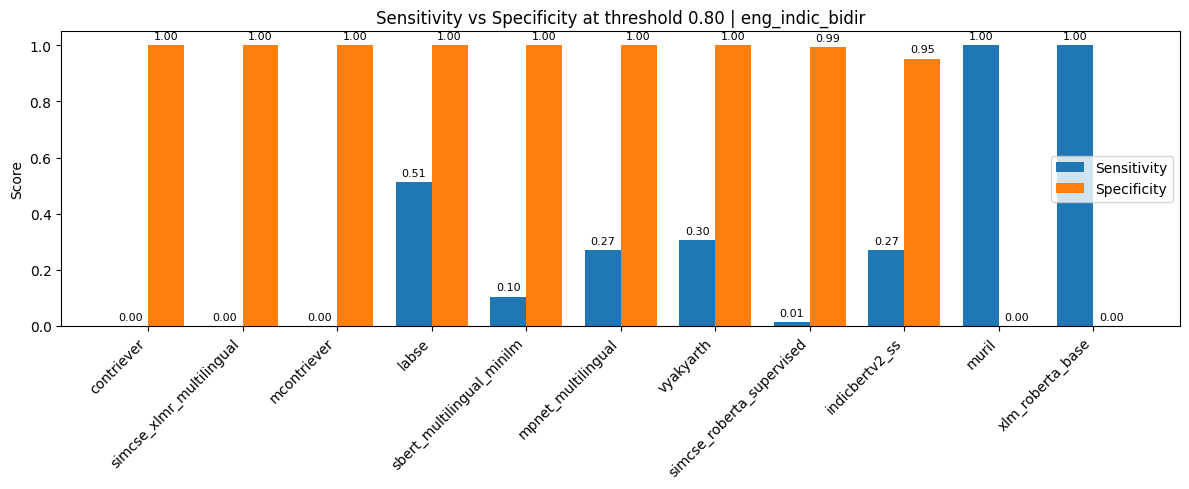

Saved plot: /content/drive/MyDrive/in22_embedding_alignment_benchmark/outputs/plots/sensitivity_specificity_t0_80_eng_indic_bidir_22sched_nfull.png


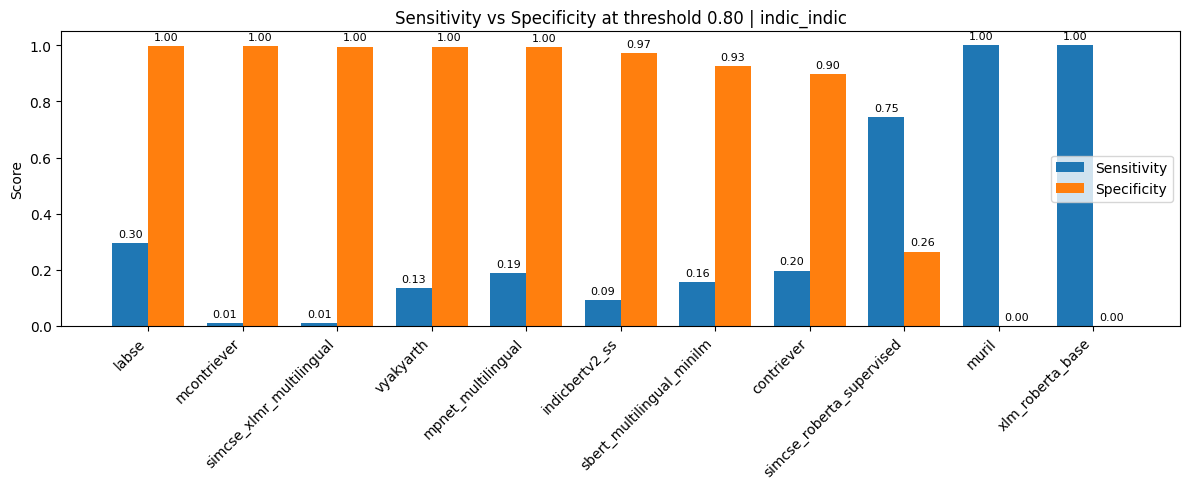

Saved plot: /content/drive/MyDrive/in22_embedding_alignment_benchmark/outputs/plots/sensitivity_specificity_t0_80_indic_indic_22sched_nfull.png


In [ ]:
def plot_sensitivity_specificity_at_threshold(df, threshold=0.80):
    tag = _threshold_tag(threshold)
    sens_col = f'sensitivity_at_{tag}'
    spec_col = f'specificity_at_{tag}'

    if sens_col not in df.columns or spec_col not in df.columns:
        raise ValueError(f'Missing {sens_col}/{spec_col}. Rerun benchmark with advanced metrics.')

    plot_df = (
        df.groupby(['model', 'benchmark_type'])[[sens_col, spec_col]]
        .mean()
        .reset_index()
    )

    # Plot separately for each benchmark type for readability.
    for benchmark_type, sub in plot_df.groupby('benchmark_type'):
        sub = sub.sort_values(spec_col, ascending=False)
        x = np.arange(len(sub))
        width = 0.38

        fig, ax = plt.subplots(figsize=(12, 5))
        b1 = ax.bar(x - width/2, sub[sens_col], width, label='Sensitivity')
        b2 = ax.bar(x + width/2, sub[spec_col], width, label='Specificity')

        ax.set_title(f'Sensitivity vs Specificity at threshold {threshold:.2f} | {benchmark_type}')
        ax.set_ylabel('Score')
        ax.set_xticks(x)
        ax.set_xticklabels(sub['model'], rotation=45, ha='right')
        ax.set_ylim(0, 1.05)
        ax.legend()

        for bars in [b1, b2]:
            ax.bar_label(bars, labels=[f'{v.get_height():.2f}' for v in bars], padding=3, fontsize=8)

        plt.tight_layout()
        path = OUTPUT_DIR / 'plots' / f'sensitivity_specificity_t{tag}_{benchmark_type}_{LANG_TAG}_n{N_TAG}.png'
        plt.savefig(path, dpi=200)
        plt.show()
        print('Saved plot:', path)

plot_sensitivity_specificity_at_threshold(metrics_df, threshold=0.80)


## 9. Plots

Since the main goal is **alignment**, the first two plots are:

1. Mean gold-pair cosine by model
2. Cosine gap by model

Accuracy@1 is plotted as a supporting retrieval/uniformity indicator.


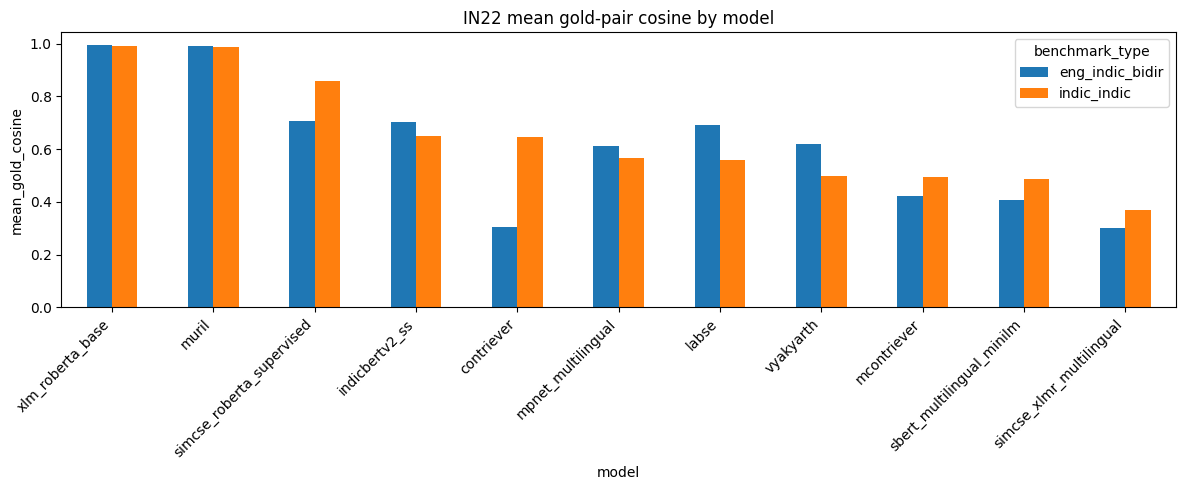

Saved plot: /content/drive/MyDrive/in22_embedding_alignment_benchmark/outputs/plots/in22_mean_gold_cosine_by_model_22sched_nfull.png


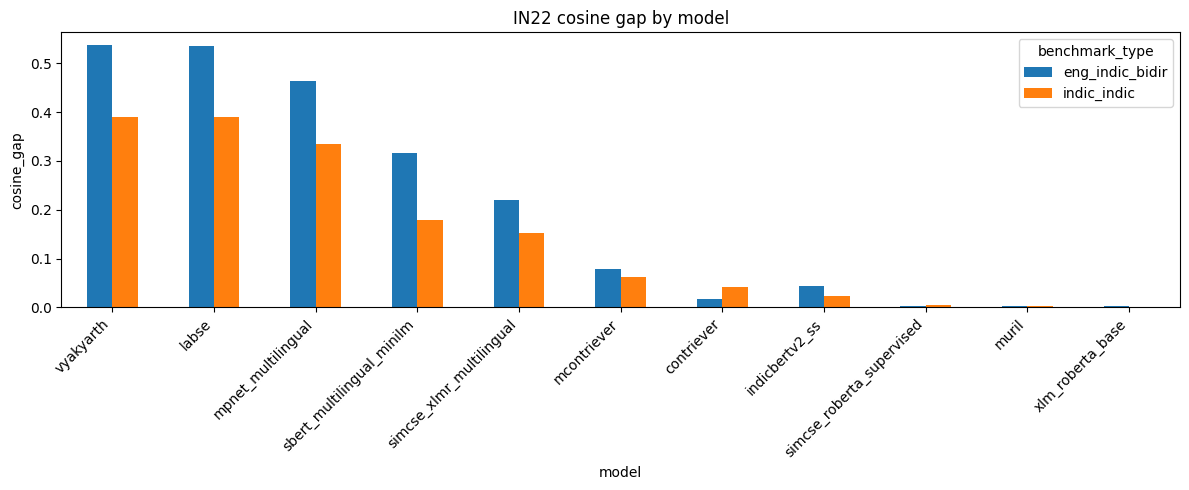

Saved plot: /content/drive/MyDrive/in22_embedding_alignment_benchmark/outputs/plots/in22_cosine_gap_by_model_22sched_nfull.png


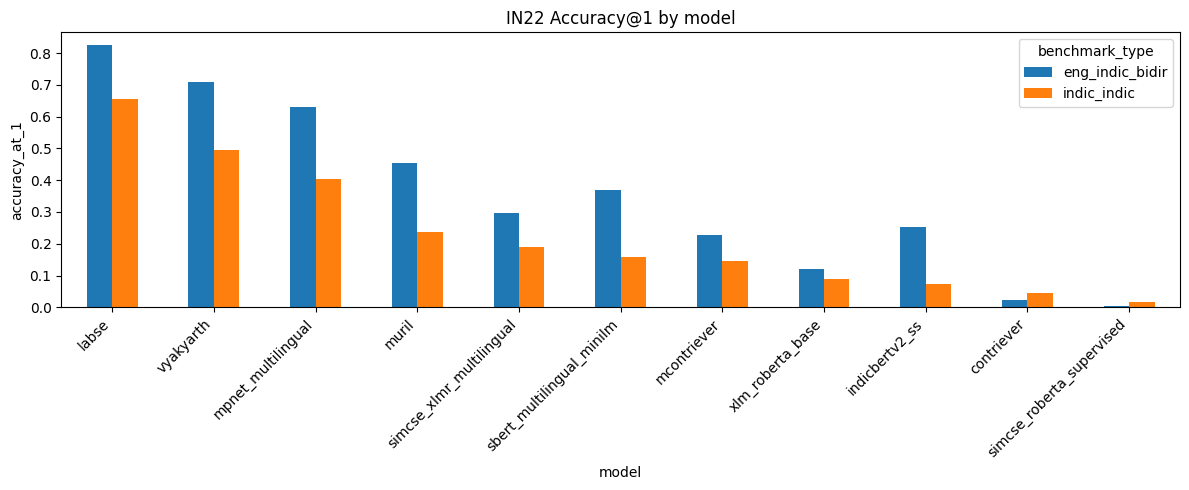

Saved plot: /content/drive/MyDrive/in22_embedding_alignment_benchmark/outputs/plots/in22_accuracy_at_1_by_model_22sched_nfull.png


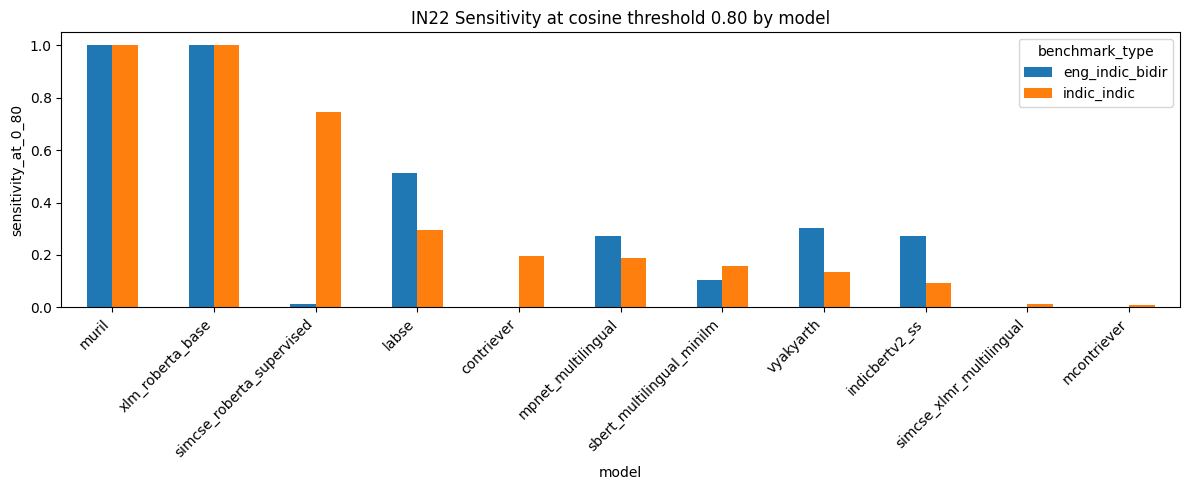

Saved plot: /content/drive/MyDrive/in22_embedding_alignment_benchmark/outputs/plots/in22_sensitivity_at_0_80_by_model_22sched_nfull.png


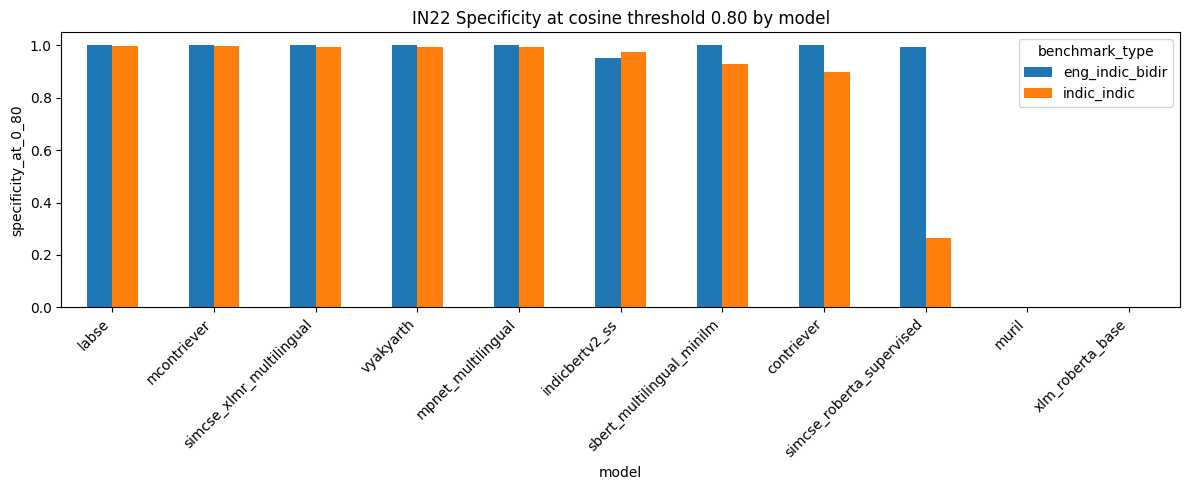

Saved plot: /content/drive/MyDrive/in22_embedding_alignment_benchmark/outputs/plots/in22_specificity_at_0_80_by_model_22sched_nfull.png


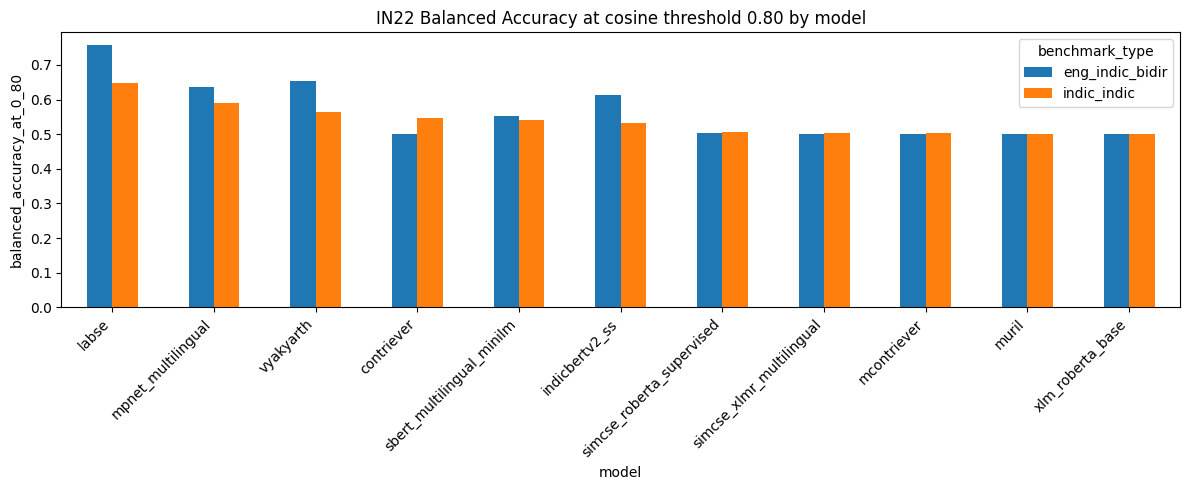

Saved plot: /content/drive/MyDrive/in22_embedding_alignment_benchmark/outputs/plots/in22_balanced_accuracy_at_0_80_by_model_22sched_nfull.png


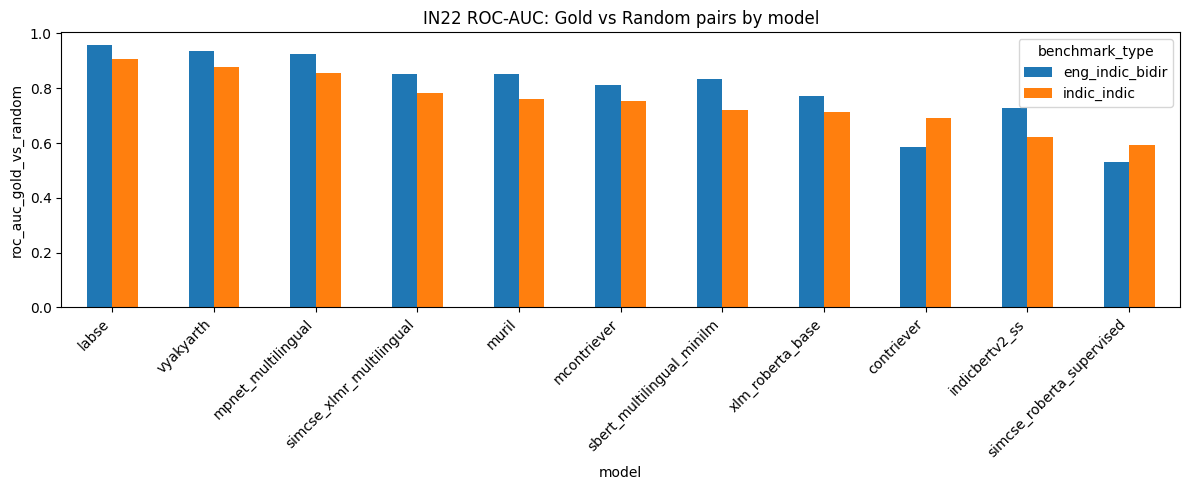

Saved plot: /content/drive/MyDrive/in22_embedding_alignment_benchmark/outputs/plots/in22_roc_auc_gold_vs_random_by_model_22sched_nfull.png


In [ ]:
def plot_metric_by_model(df, metric, title, filename):
    plot_df = (
        df.groupby(['model', 'benchmark_type'])[metric]
        .mean()
        .reset_index()
        .pivot(index='model', columns='benchmark_type', values=metric)
    )
    # Sort by Indic-Indic value if present; otherwise by first column.
    sort_col = 'indic_indic' if 'indic_indic' in plot_df.columns else plot_df.columns[0]
    plot_df = plot_df.sort_values(sort_col, ascending=False)

    ax = plot_df.plot(kind='bar', figsize=(12, 5))
    ax.set_ylabel(metric)
    ax.set_title(title)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    path = OUTPUT_DIR / 'plots' / filename
    plt.savefig(path, dpi=200)
    plt.show()
    print('Saved plot:', path)

plot_metric_by_model(
    metrics_df,
    'mean_gold_cosine',
    'IN22 mean gold-pair cosine by model',
    f'in22_mean_gold_cosine_by_model_{LANG_TAG}_n{N_TAG}.png'
)

plot_metric_by_model(
    metrics_df,
    'cosine_gap',
    'IN22 cosine gap by model',
    f'in22_cosine_gap_by_model_{LANG_TAG}_n{N_TAG}.png'
)

plot_metric_by_model(
    metrics_df,
    'accuracy_at_1',
    'IN22 Accuracy@1 by model',
    f'in22_accuracy_at_1_by_model_{LANG_TAG}_n{N_TAG}.png'
)

# Professor-requested diagnostic plots.
for metric_name, title_suffix in [
    ('sensitivity_at_0_80', 'Sensitivity at cosine threshold 0.80'),
    ('specificity_at_0_80', 'Specificity at cosine threshold 0.80'),
    ('balanced_accuracy_at_0_80', 'Balanced Accuracy at cosine threshold 0.80'),
    ('roc_auc_gold_vs_random', 'ROC-AUC: Gold vs Random pairs'),
]:
    if metric_name in metrics_df.columns:
        plot_metric_by_model(
            metrics_df,
            metric_name,
            f'IN22 {title_suffix} by model',
            f'in22_{metric_name}_by_model_{LANG_TAG}_n{N_TAG}.png'
        )


## 10. Heatmap for one model

Use this to inspect model performance pair-by-pair.


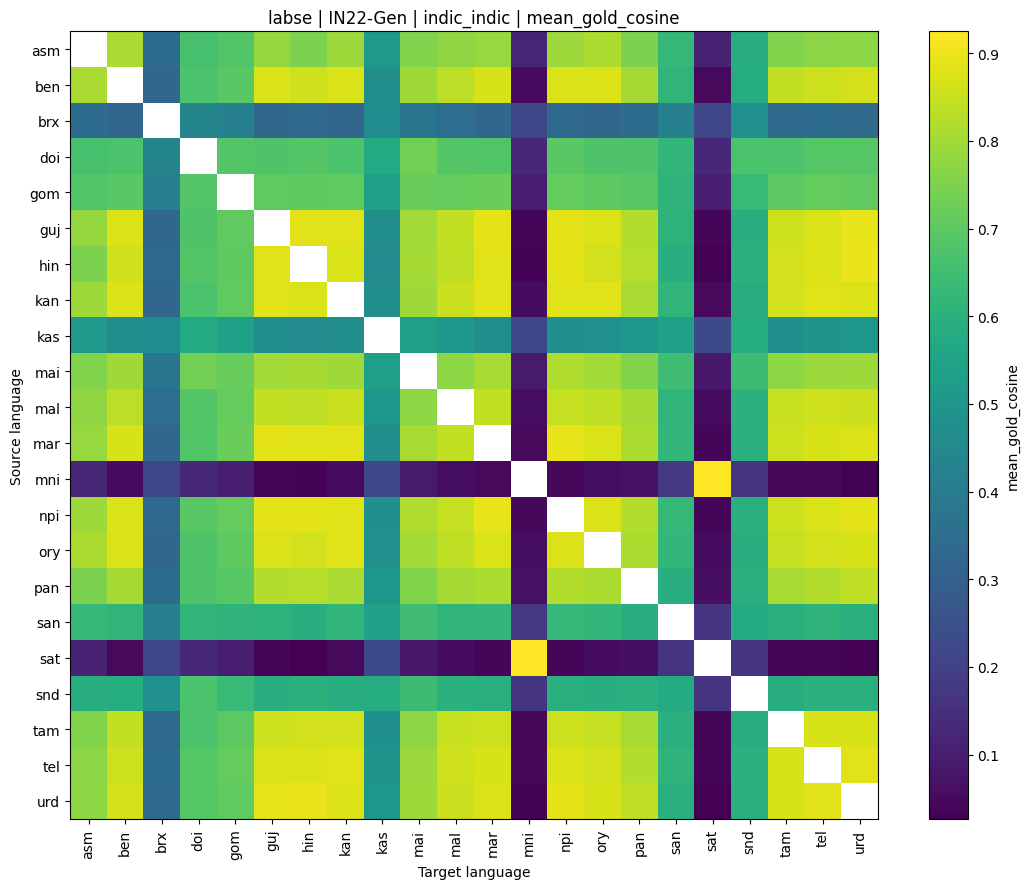

Saved heatmap: /content/drive/MyDrive/in22_embedding_alignment_benchmark/outputs/plots/heatmap_labse_IN22-Gen_indic_indic_mean_gold_cosine_22sched_nfull.png


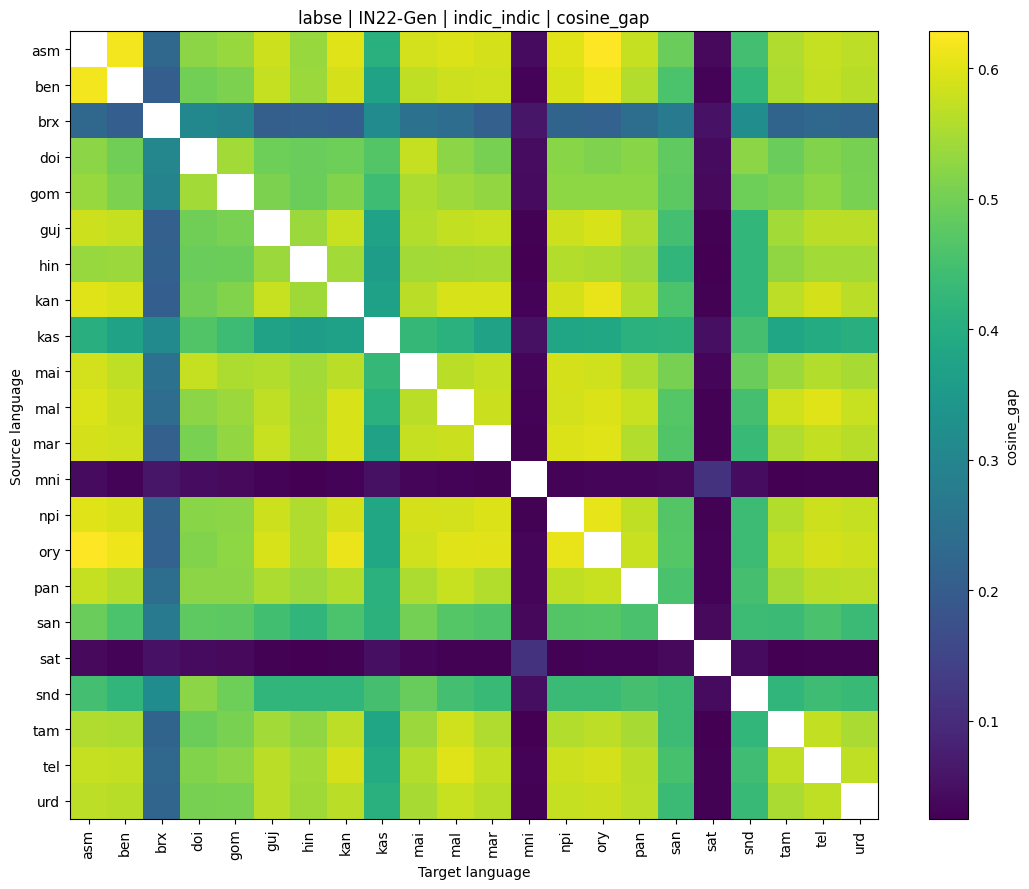

Saved heatmap: /content/drive/MyDrive/in22_embedding_alignment_benchmark/outputs/plots/heatmap_labse_IN22-Gen_indic_indic_cosine_gap_22sched_nfull.png


In [ ]:
def plot_heatmap_for_model(df, model_name, dataset_suite='IN22-Gen', benchmark_type='indic_indic', metric='cosine_gap'):
    sub = df[
        (df['model'] == model_name) &
        (df['dataset_suite'] == dataset_suite) &
        (df['benchmark_type'] == benchmark_type)
    ].copy()

    if sub.empty:
        print('No rows found for this selection.')
        return

    heat = sub.pivot(index='source_language', columns='target_language', values=metric)

    plt.figure(figsize=(11, 9))
    plt.imshow(heat, aspect='auto')
    plt.colorbar(label=metric)
    plt.xticks(range(len(heat.columns)), heat.columns, rotation=90)
    plt.yticks(range(len(heat.index)), heat.index)
    plt.title(f'{model_name} | {dataset_suite} | {benchmark_type} | {metric}')
    plt.xlabel('Target language')
    plt.ylabel('Source language')
    plt.tight_layout()

    path = OUTPUT_DIR / 'plots' / f'heatmap_{model_name}_{dataset_suite}_{benchmark_type}_{metric}_{LANG_TAG}_n{N_TAG}.png'
    plt.savefig(path, dpi=200)
    plt.show()
    print('Saved heatmap:', path)

# Example heatmaps for LaBSE.
plot_heatmap_for_model(metrics_df, 'labse', dataset_suite='IN22-Gen', benchmark_type='indic_indic', metric='mean_gold_cosine')
plot_heatmap_for_model(metrics_df, 'labse', dataset_suite='IN22-Gen', benchmark_type='indic_indic', metric='cosine_gap')

## 10A. Gold vs random cosine distribution diagnostic

Use this cell when a model has high mean cosine but low cosine gap. It plots the score distribution of true translation pairs and random/wrong pairs for one selected model and language direction.


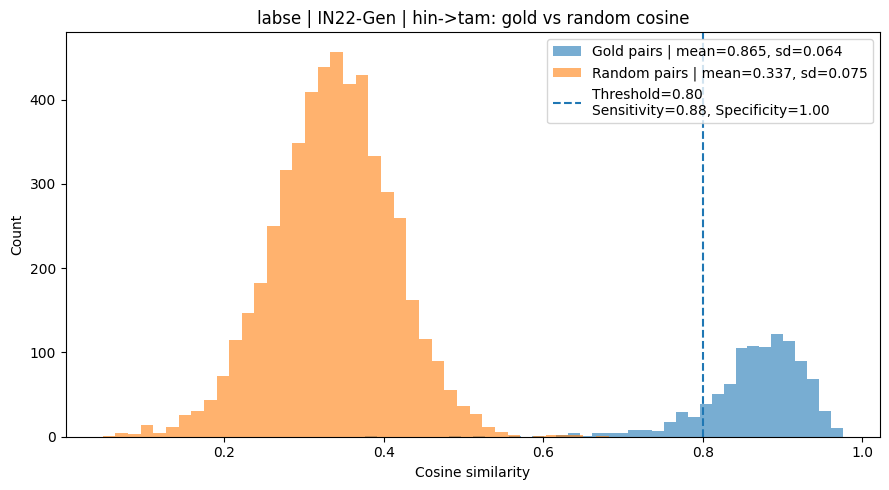

Saved plot: /content/drive/MyDrive/in22_embedding_alignment_benchmark/outputs/plots/distribution_labse_IN22-Gen_hin-tam_t0_80_22sched_nfull.png


In [ ]:
def load_cached_embedding(model_name: str, suite_name: str, lang: str) -> np.ndarray:
    path = OUTPUT_DIR / 'embeddings' / f"{model_name}_{suite_name}_{LANG_TAG}_{lang}_n{N_TAG}_l{MAX_LENGTH}.npy"
    if not path.exists():
        raise FileNotFoundError(f'Embedding cache not found: {path}')
    return np.load(path)


def plot_gold_vs_random_distribution(
    model_name: str = 'labse',
    suite_name: str = 'IN22-Gen',
    src_lang: str = 'hin',
    tgt_lang: str = 'tam',
    threshold: float = 0.80,
    negative_samples_per_pos: int = NEGATIVE_SAMPLES_PER_POS,
):
    src_emb = load_cached_embedding(model_name, suite_name, src_lang)
    tgt_emb = load_cached_embedding(model_name, suite_name, tgt_lang)

    sim = cosine_sim_matrix(src_emb, tgt_emb)
    gold = np.diag(sim)
    neg = sample_random_negatives_from_similarity(
        sim,
        seed=SEED,
        negative_samples_per_pos=negative_samples_per_pos,
    )

    sens = np.mean(gold >= threshold)
    spec = np.mean(neg < threshold)

    plt.figure(figsize=(9, 5))
    plt.hist(gold, bins=40, alpha=0.6, label=f'Gold pairs | mean={gold.mean():.3f}, sd={gold.std():.3f}')
    plt.hist(neg, bins=40, alpha=0.6, label=f'Random pairs | mean={neg.mean():.3f}, sd={neg.std():.3f}')
    plt.axvline(threshold, linestyle='--', label=f'Threshold={threshold:.2f}\nSensitivity={sens:.2f}, Specificity={spec:.2f}')
    plt.xlabel('Cosine similarity')
    plt.ylabel('Count')
    plt.title(f'{model_name} | {suite_name} | {src_lang}->{tgt_lang}: gold vs random cosine')
    plt.legend()
    plt.tight_layout()

    tag = _threshold_tag(threshold)
    path = OUTPUT_DIR / 'plots' / f'distribution_{model_name}_{suite_name}_{src_lang}-{tgt_lang}_t{tag}_{LANG_TAG}_n{N_TAG}.png'
    plt.savefig(path, dpi=200)
    plt.show()
    print('Saved plot:', path)

# Example: change model_name / language pair to inspect suspicious models such as xlm_roberta_base or muril.
plot_gold_vs_random_distribution(model_name='labse', suite_name='IN22-Gen', src_lang='hin', tgt_lang='tam', threshold=0.80)


## 11. Best and weakest Indic–Indic directions

This helps find which Indic–Indic pairs are strongest/weakest for each model.


In [ ]:
indic_indic_df = metrics_df[metrics_df['benchmark_type'] == 'indic_indic'].copy()

best_pairs = (
    indic_indic_df
    .sort_values(['model', 'cosine_gap'], ascending=[True, False])
    .groupby('model')
    .head(10)
)

weakest_pairs = (
    indic_indic_df
    .sort_values(['model', 'cosine_gap'], ascending=[True, True])
    .groupby('model')
    .head(10)
)

best_path = OUTPUT_DIR / 'metrics' / f'in22_best_indic_indic_pairs_by_cosine_gap_{LANG_TAG}_n{N_TAG}.csv'
weak_path = OUTPUT_DIR / 'metrics' / f'in22_weakest_indic_indic_pairs_by_cosine_gap_{LANG_TAG}_n{N_TAG}.csv'
best_pairs.to_csv(best_path, index=False)
weakest_pairs.to_csv(weak_path, index=False)

print('Saved:', best_path)
display(best_pairs[['dataset_suite', 'model', 'language_pair', 'mean_gold_cosine', 'mean_random_cosine', 'cosine_gap', 'accuracy_at_1', 'mrr']])

print('Saved:', weak_path)
display(weakest_pairs[['dataset_suite', 'model', 'language_pair', 'mean_gold_cosine', 'mean_random_cosine', 'cosine_gap', 'accuracy_at_1', 'mrr']])

Saved: /content/drive/MyDrive/in22_embedding_alignment_benchmark/outputs/metrics/in22_best_indic_indic_pairs_by_cosine_gap_22sched_nfull.csv


,dataset_suite,model,language_pair,mean_gold_cosine,mean_random_cosine,cosine_gap,accuracy_at_1,mrr
10550,IN22-Conv,contriever,tel-mal,0.956396,0.838434,0.117961,0.136394,0.171719
10349,IN22-Conv,contriever,mal-tel,0.956396,0.838513,0.117882,0.139721,0.173547
10380,IN22-Conv,contriever,mar-gom,0.860233,0.743523,0.116710,0.246840,0.329100
10299,IN22-Conv,contriever,gom-mar,0.860233,0.743811,0.116421,0.268796,0.351806
10265,IN22-Conv,contriever,kan-tel,0.945873,0.832988,0.112885,0.140386,0.181365
...,...,...,...,...,...,...,...,...
9032,IN22-Conv,xlm_roberta_base,tel-mal,0.995488,0.991516,0.003973,0.079840,0.152375
8816,IN22-Conv,xlm_roberta_base,mal-guj,0.995233,0.991429,0.003803,0.170991,0.245516
9026,IN22-Conv,xlm_roberta_base,tel-guj,0.995598,0.991819,0.003779,0.144378,0.217002
8704,IN22-Conv,xlm_roberta_base,guj-tam,0.995201,0.991423,0.003778,0.103792,0.161747


Saved: /content/drive/MyDrive/in22_embedding_alignment_benchmark/outputs/metrics/in22_weakest_indic_indic_pairs_by_cosine_gap_22sched_nfull.csv


,dataset_suite,model,language_pair,mean_gold_cosine,mean_random_cosine,cosine_gap,accuracy_at_1,mrr
5009,IN22-Gen,contriever,urd-ory,0.558781,0.549299,0.009482,0.007812,0.025051
10252,IN22-Conv,contriever,kan-kas,0.563354,0.553409,0.009945,0.001331,0.010559
10567,IN22-Conv,contriever,urd-kan,0.530300,0.520330,0.009970,0.002661,0.008469
10266,IN22-Conv,contriever,kan-urd,0.530300,0.520263,0.010037,0.002661,0.012203
5012,IN22-Gen,contriever,urd-sat,0.549511,0.539461,0.010051,0.006836,0.021936
...,...,...,...,...,...,...,...,...
3400,IN22-Gen,xlm_roberta_base,sat-kas,0.985312,0.985016,0.000296,0.002930,0.011346
3452,IN22-Gen,xlm_roberta_base,tam-sat,0.978839,0.978542,0.000297,0.000977,0.010005
3412,IN22-Gen,xlm_roberta_base,sat-tel,0.979482,0.979173,0.000309,0.003906,0.012306
3411,IN22-Gen,xlm_roberta_base,sat-tam,0.978839,0.978530,0.000309,0.001953,0.011345


## Final interpretation guide

Use this logic in your report:

- **High mean gold cosine + high cosine gap**: strong alignment and good separation.
- **High mean gold cosine + low cosine gap**: correct translations are close, but wrong/random sentences are also close. This indicates weak specificity and weak uniformity/separation.
- **High sensitivity + low specificity**: the model accepts true pairs, but also falsely accepts many wrong pairs. This is the exact issue the professor pointed out.
- **High sensitivity + high specificity**: the model separates true translation pairs from wrong pairs well.
- **ROC-AUC / balanced accuracy**: threshold-based summary of how well gold and random pair distributions are separated.
- **Accuracy@1 / MRR**: supporting retrieval evidence showing whether the correct translation is ranked above candidates.

For the mentor’s current question, prioritize **Indic–Indic mean ± s.d., cosine gap, sensitivity, specificity**, and then use Accuracy@1/MRR as supporting evidence.


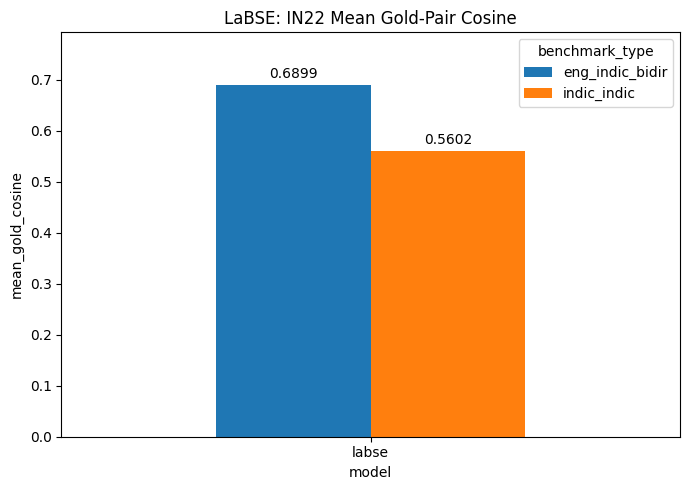

Saved plot: /content/drive/MyDrive/in22_embedding_alignment_benchmark/outputs/plots/labse_in22_mean_gold_cosine_22sched_nfull.png


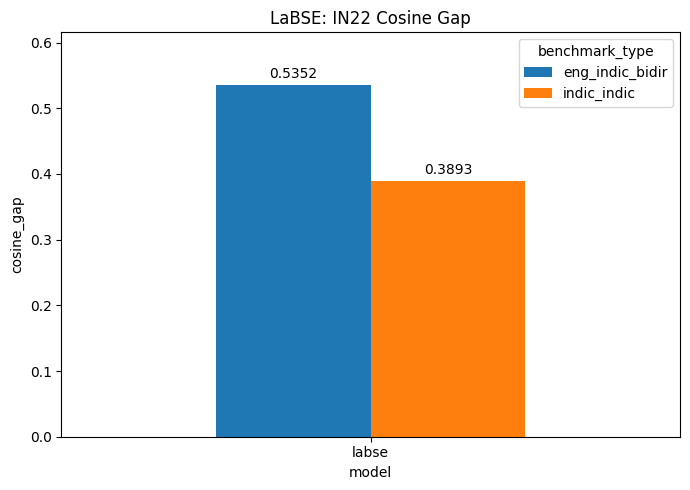

Saved plot: /content/drive/MyDrive/in22_embedding_alignment_benchmark/outputs/plots/labse_in22_cosine_gap_22sched_nfull.png


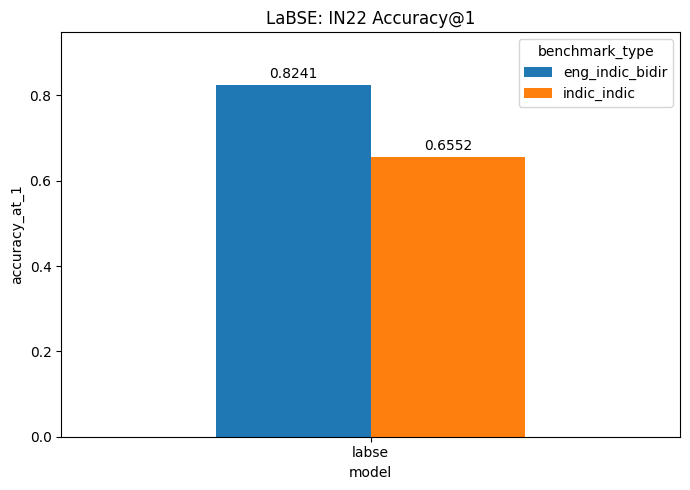

Saved plot: /content/drive/MyDrive/in22_embedding_alignment_benchmark/outputs/plots/labse_in22_accuracy_at_1_22sched_nfull.png


In [ ]:
def plot_labse_metric(df, metric, title, filename):
    # Keep only LaBSE rows
    labse_df = df[df["model"].str.lower() == "labse"].copy()

    if labse_df.empty:
        raise ValueError("No rows found for model = labse")

    plot_df = (
        labse_df.groupby(["model", "benchmark_type"])[metric]
        .mean()
        .reset_index()
        .pivot(index="model", columns="benchmark_type", values=metric)
    )

    ax = plot_df.plot(kind="bar", figsize=(7, 5))

    ax.set_ylabel(metric)
    ax.set_title(title)
    plt.xticks(rotation=0)

    # Write score on top of each bar
    for container in ax.containers:
        ax.bar_label(
            container,
            labels=[f"{v.get_height():.4f}" for v in container],
            padding=3,
            fontsize=10
        )

    # Give extra space above bars for labels
    max_value = plot_df.max().max()
    ax.set_ylim(0, max_value * 1.15)

    plt.tight_layout()

    path = OUTPUT_DIR / "plots" / filename
    plt.savefig(path, dpi=200)
    plt.show()

    print("Saved plot:", path)


plot_labse_metric(
  metrics_df,
  "mean_gold_cosine",
  "LaBSE: IN22 Mean Gold-Pair Cosine",
  f"labse_in22_mean_gold_cosine_{LANG_TAG}_n{N_TAG}.png"
)

plot_labse_metric(
  metrics_df,
  "cosine_gap",
  "LaBSE: IN22 Cosine Gap",
  f"labse_in22_cosine_gap_{LANG_TAG}_n{N_TAG}.png"
)

plot_labse_metric(
  metrics_df,
  "accuracy_at_1",
  "LaBSE: IN22 Accuracy@1",
  f"labse_in22_accuracy_at_1_{LANG_TAG}_n{N_TAG}.png"
)

In [ ]:
# ------------------------------------------------------------
# Table: Model-wise mean cosine similarity and cosine gap
# ------------------------------------------------------------

model_alignment_table = (
    metrics_df
    .groupby(["model", "benchmark_type"])[
        ["mean_gold_cosine", "mean_random_cosine", "cosine_gap"]
    ]
    .mean()
    .reset_index()
    .sort_values(["benchmark_type", "cosine_gap"], ascending=[True, False])
)

model_alignment_path = (
    OUTPUT_DIR
    / "metrics"
    / f"in22_model_mean_cosine_and_gap_{LANG_TAG}_n{N_TAG}.csv"
)

model_alignment_table.to_csv(model_alignment_path, index=False)

print("Saved:", model_alignment_path)
display(model_alignment_table)

Saved: /content/drive/MyDrive/in22_embedding_alignment_benchmark/outputs/metrics/in22_model_mean_cosine_and_gap_22sched_nfull.csv


,model,benchmark_type,mean_gold_cosine,mean_random_cosine,cosine_gap
18,vyakyarth,eng_indic_bidir,0.617812,0.081446,0.536366
4,labse,eng_indic_bidir,0.689867,0.154651,0.535216
8,mpnet_multilingual,eng_indic_bidir,0.610931,0.146746,0.464186
12,sbert_multilingual_minilm,eng_indic_bidir,0.408049,0.092709,0.315340
16,simcse_xlmr_multilingual,eng_indic_bidir,0.302304,0.081655,0.220649
6,mcontriever,eng_indic_bidir,0.420515,0.341546,0.078968
2,indicbertv2_ss,eng_indic_bidir,0.703286,0.658575,0.044711
0,contriever,eng_indic_bidir,0.304246,0.286219,0.018028
14,simcse_roberta_supervised,eng_indic_bidir,0.705035,0.701352,0.003683
10,muril,eng_indic_bidir,0.989351,0.986802,0.002549


In [ ]:
# ------------------------------------------------------------
# Full names for IN22 languages
# ------------------------------------------------------------

LANG_FULL_NAMES = {
    "asm": "Assamese",
    "ben": "Bengali",
    "brx": "Bodo",
    "doi": "Dogri",
    "gom": "Konkani",
    "guj": "Gujarati",
    "hin": "Hindi",
    "kan": "Kannada",
    "kas": "Kashmiri",
    "mai": "Maithili",
    "mal": "Malayalam",
    "mar": "Marathi",
    "mni": "Manipuri / Meitei",
    "npi": "Nepali",
    "ory": "Odia",
    "pan": "Punjabi",
    "san": "Sanskrit",
    "sat": "Santali",
    "snd": "Sindhi",
    "tam": "Tamil",
    "tel": "Telugu",
    "urd": "Urdu",
}
# ------------------------------------------------------------
# LaBSE Indic-Indic language ranking: best to worst
# Includes full language name
# ------------------------------------------------------------

labse_indic_df = metrics_df[
    (metrics_df["model"].str.lower() == "labse") &
    (metrics_df["benchmark_type"] == "indic_indic")
].copy()

if labse_indic_df.empty:
    raise ValueError("No LaBSE Indic-Indic rows found. Check model name / benchmark_type.")

# Source-side performance:
# How well each language performs when used as SOURCE language.
source_rank = (
    labse_indic_df
    .groupby("source_language")[
        ["mean_gold_cosine", "mean_random_cosine", "cosine_gap",
         "accuracy_at_1", "recall_at_10", "mrr"]
    ]
    .mean()
    .reset_index()
    .rename(columns={"source_language": "language"})
)

source_rank["role"] = "source"

# Target-side performance:
# How well each language performs when used as TARGET language.
target_rank = (
    labse_indic_df
    .groupby("target_language")[
        ["mean_gold_cosine", "mean_random_cosine", "cosine_gap",
         "accuracy_at_1", "recall_at_10", "mrr"]
    ]
    .mean()
    .reset_index()
    .rename(columns={"target_language": "language"})
)

target_rank["role"] = "target"

# Overall language performance:
# Average both source-side and target-side behaviour.
language_rank = (
    pd.concat([source_rank, target_rank], ignore_index=True)
    .groupby("language")[
        ["mean_gold_cosine", "mean_random_cosine", "cosine_gap",
         "accuracy_at_1", "recall_at_10", "mrr"]
    ]
    .mean()
    .reset_index()
)

# Add full language name
language_rank["language_name"] = language_rank["language"].map(LANG_FULL_NAMES)

# If any full name is missing, keep the code itself as fallback
language_rank["language_name"] = language_rank["language_name"].fillna(language_rank["language"])

# Sort best to worst.
# Since alignment is the focus, cosine_gap is the main ranking metric.
# Accuracy@1 is used as secondary ranking signal.
language_rank = language_rank.sort_values(
    ["cosine_gap", "accuracy_at_1"],
    ascending=[False, False]
).reset_index(drop=True)

language_rank.insert(0, "rank", range(1, len(language_rank) + 1))

# Reorder columns nicely
language_rank = language_rank[
    [
        "rank",
        "language",
        "language_name",
        "mean_gold_cosine",
        "mean_random_cosine",
        "cosine_gap",
        "accuracy_at_1",
        "recall_at_10",
        "mrr",
    ]
]

# Save table
language_rank_path = (
    OUTPUT_DIR
    / "metrics"
    / f"labse_indic_indic_language_ranking_{LANG_TAG}_n{N_TAG}.csv"
)

language_rank.to_csv(language_rank_path, index=False)

print("Saved:", language_rank_path)
display(language_rank)

Saved: /content/drive/MyDrive/in22_embedding_alignment_benchmark/outputs/metrics/labse_indic_indic_language_ranking_22sched_nfull.csv


,rank,language,language_name,mean_gold_cosine,mean_random_cosine,cosine_gap,accuracy_at_1,recall_at_10,mrr
0,1,asm,Assamese,0.636701,0.168083,0.468618,0.779547,0.848552,0.804725
1,2,ory,Odia,0.666803,0.200353,0.466450,0.786107,0.846332,0.808251
2,3,npi,Nepali,0.675831,0.213682,0.462149,0.791761,0.847288,0.812076
3,4,mal,Malayalam,0.654639,0.196309,0.458330,0.776109,0.841313,0.799946
4,5,mar,Marathi,0.673290,0.215744,0.457546,0.787540,0.844711,0.808528
5,6,ben,Bengali,0.668825,0.211325,0.457500,0.786758,0.845521,0.808319
6,7,tel,Telugu,0.665511,0.211029,0.454483,0.781573,0.843312,0.804093
7,8,pan,Punjabi,0.649484,0.195838,0.453646,0.785573,0.845978,0.807691
8,9,urd,Urdu,0.672937,0.221119,0.451819,0.791442,0.846149,0.811472
9,10,kan,Kannada,0.648612,0.198064,0.450548,0.760761,0.833088,0.787345


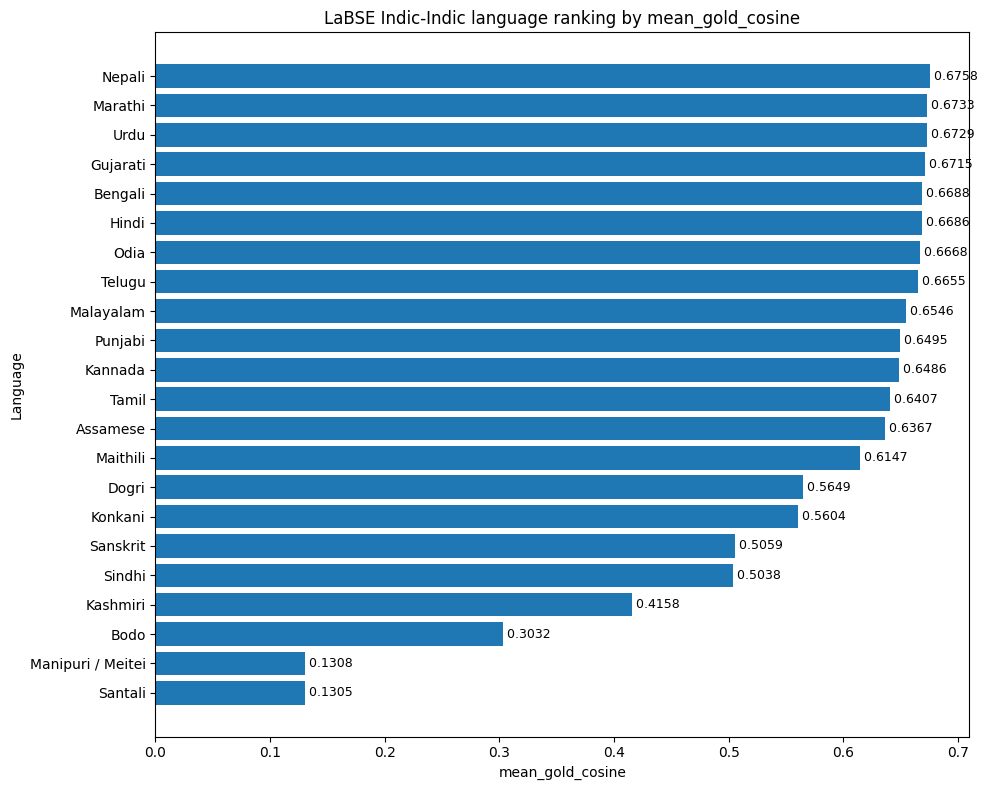

Saved plot: /content/drive/MyDrive/in22_embedding_alignment_benchmark/outputs/plots/labse_indic_indic_language_ranking_mean_gold_cosine_22sched_nfull.png


In [ ]:
# ------------------------------------------------------------
# Plot 1: LaBSE Indic-Indic language ranking
# Easy horizontal bar chart with full names and values
# ------------------------------------------------------------

(OUTPUT_DIR / "plots").mkdir(parents=True, exist_ok=True)

def plot_labse_language_ranking(language_rank, metric="mean_gold_cosine"):
    plot_df = language_rank.sort_values(metric, ascending=True).copy()

    plt.figure(figsize=(10, 8))
    ax = plt.gca()

    bars = ax.barh(
        plot_df["language_name"],
        plot_df[metric]
    )

    ax.set_xlabel(metric)
    ax.set_ylabel("Language")
    ax.set_title(f"LaBSE Indic-Indic language ranking by {metric}")

    # Write value at the end of each bar
    for bar in bars:
        width = bar.get_width()
        ax.text(
            width,
            bar.get_y() + bar.get_height() / 2,
            f" {width:.4f}",
            va="center",
            fontsize=9
        )

    plt.tight_layout()

    plot_path = OUTPUT_DIR / "plots" / f"labse_indic_indic_language_ranking_{metric}_{LANG_TAG}_n{N_TAG}.png"
    plt.savefig(plot_path, dpi=200)
    plt.show()

    print("Saved plot:", plot_path)


plot_labse_language_ranking(language_rank, metric="mean_gold_cosine")


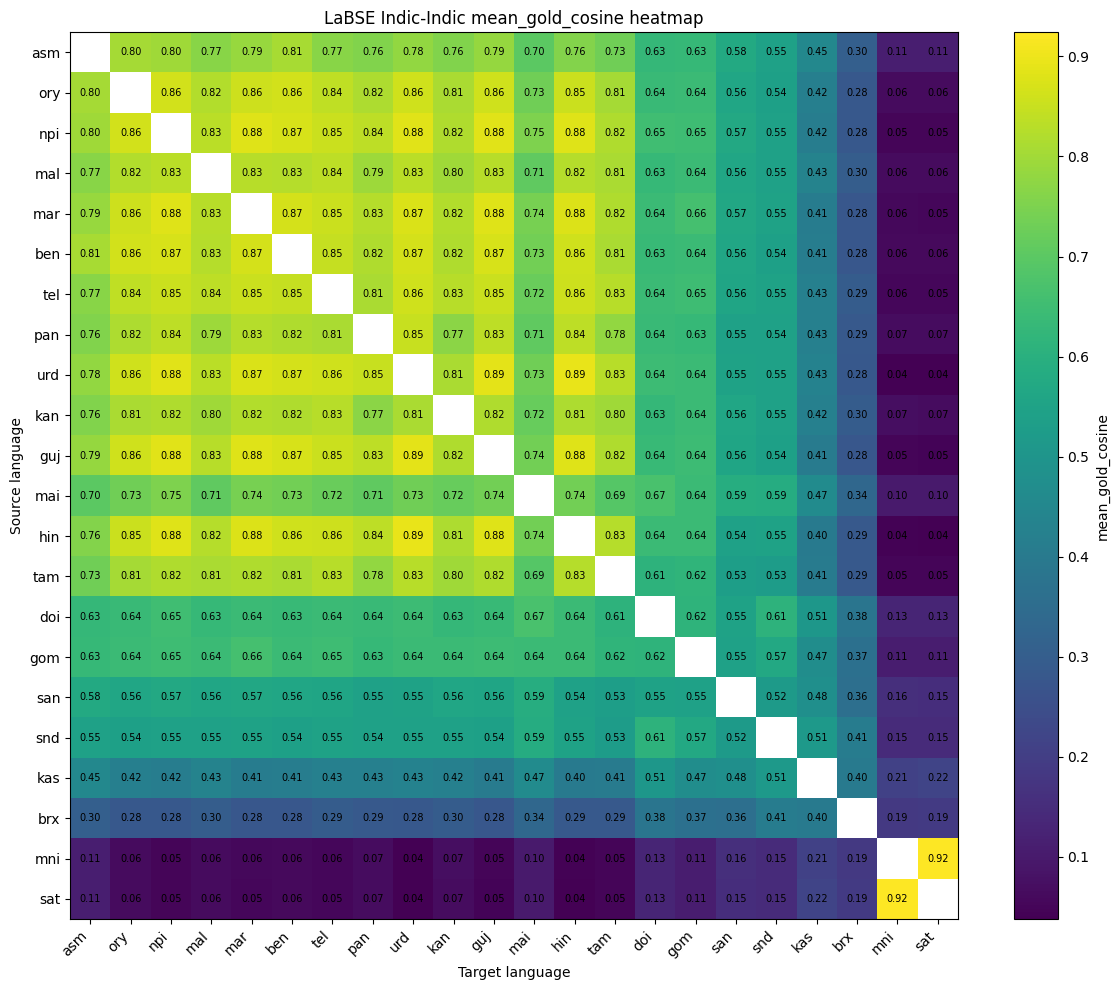

Saved heatmap: /content/drive/MyDrive/in22_embedding_alignment_benchmark/outputs/plots/labse_indic_indic_heatmap_mean_gold_cosine_22sched_nfull.png


In [ ]:
def plot_labse_indic_heatmap(metrics_df, metric="mean_gold_cosine"):
    labse_indic_df = metrics_df[
        (metrics_df["model"].str.lower() == "labse") &
        (metrics_df["benchmark_type"] == "indic_indic")
    ].copy()

    if labse_indic_df.empty:
        raise ValueError("No LaBSE Indic-Indic rows found.")

    # Average duplicate rows across IN22-Gen and IN22-Conv
    heatmap_data = labse_indic_df.pivot_table(
        index="source_language",
        columns="target_language",
        values=metric,
        aggfunc="mean"
    )

    # Use language ranking order if available
    if "language_rank" in globals():
        lang_order = language_rank["language"].tolist()
        heatmap_data = heatmap_data.reindex(index=lang_order, columns=lang_order)

    plt.figure(figsize=(12, 10))
    ax = plt.gca()

    im = ax.imshow(heatmap_data, aspect="auto")
    plt.colorbar(im, label=metric)

    ax.set_xticks(range(len(heatmap_data.columns)))
    ax.set_xticklabels(heatmap_data.columns, rotation=45, ha="right")

    ax.set_yticks(range(len(heatmap_data.index)))
    ax.set_yticklabels(heatmap_data.index)

    ax.set_xlabel("Target language")
    ax.set_ylabel("Source language")
    ax.set_title(f"LaBSE Indic-Indic {metric} heatmap")

    # Write values inside cells
    for i in range(len(heatmap_data.index)):
        for j in range(len(heatmap_data.columns)):
            value = heatmap_data.iloc[i, j]
            if not pd.isna(value):
                ax.text(
                    j, i,
                    f"{value:.2f}",
                    ha="center",
                    va="center",
                    fontsize=7
                )

    plt.tight_layout()

    plot_path = (
        OUTPUT_DIR
        / "plots"
        / f"labse_indic_indic_heatmap_{metric}_{LANG_TAG}_n{N_TAG}.png"
    )

    plt.savefig(plot_path, dpi=200)
    plt.show()

    print("Saved heatmap:", plot_path)
plot_labse_indic_heatmap(metrics_df, metric="mean_gold_cosine")